# Multivariable Calculus — Interactive Visualization

> **MLVerse-Math | Chapter 08: Multivariable Calculus**

---

## Introduction

Multivariable calculus is the **mathematical language of optimization** and the foundation of modern artificial intelligence. From training deep neural networks to controlling robotic arms, from detecting edges in computer vision to modeling probability distributions — every advanced AI system relies on the concepts explored in this notebook.

### Why This Matters for AI

- **Neural Networks**: Gradient descent optimizes loss functions in millions of dimensions
- **Computer Vision**: Image gradients power edge detection and feature extraction
- **Robotics**: Jacobian matrices map joint velocities to end-effector motion
- **Generative Models**: Probability distributions live in high-dimensional spaces
- **Transformers**: Attention mechanisms are differentiable operations in tensor spaces

### Learning Path

This notebook progresses from **Beginner → Intermediate → Advanced**:

1. **Visual Intuition** — See how functions of multiple variables form surfaces
2. **Derivatives & Gradients** — Understand rates of change and steepest ascent
3. **Optimization** — Explore loss landscapes and gradient descent
4. **AI Applications** — Connect calculus to real machine learning systems

---

**Let's begin the journey from functions to modern AI.** 🚀


In [2]:
# ============================================
# Setup & Imports
# ============================================
import numpy as np
import sympy as sp
from sympy import symbols, diff, sin, cos, exp, sqrt, lambdify, latex, simplify
from scipy import optimize, integrate
from scipy.linalg import eigvals

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.offline as pyo

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, HBox, VBox, Layout
from IPython.display import display, HTML, Math, clear_output

# Enable interactive matplotlib
# %matplotlib widget

# Set global plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ All libraries loaded successfully!")
print("📦 NumPy:", np.__version__)
print("📦 SymPy:", sp.__version__)
print("📦 Matplotlib:", plt.matplotlib.__version__)
print("📦 Plotly:", go)


✅ All libraries loaded successfully!
📦 NumPy: 2.4.6
📦 SymPy: 1.14.0
📦 Matplotlib: 3.10.9
📦 Plotly: <module 'plotly.graph_objects' from 'e:\\Organization\\ML-Verse\\mlverse-machine-learning\\venv\\Lib\\site-packages\\plotly\\graph_objects\\__init__.py'>


---

# Section 1 — Understanding Multivariable Functions

A **multivariable function** takes multiple inputs and produces a single output:

$$
f: \mathbb{R}^n \rightarrow \mathbb{R}
$$

For two variables, we write:

$$
f(x, y)
$$

## Key Examples

### 1. Paraboloid (Bowl Shape)
$$
f(x, y) = x^2 + y^2
$$

### 2. Saddle Surface
$$
f(x, y) = x^2 - y^2
$$

### 3. Sinusoidal Wave
$$
f(x, y) = \sin(x) \cos(y)
$$

## Visual Intuition

Unlike single-variable functions $f(x)$ which produce curves, multivariable functions produce **surfaces** in 3D space. The height $z = f(x, y)$ at each point $(x, y)$ creates a landscape that we can explore, optimize, and analyze.

> 💡 **Learning Goal**: Understand how functions of two variables form surfaces, and how changing $x$ and $y$ independently affects the output.


In [3]:
# ============================================
# Section 1 — Interactive 3D Surface Explorer
# ============================================

def plot_interactive_surface(func_name='Paraboloid'):
    """Plot an interactive 3D surface with selectable functions."""
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)

    functions = {
        'Paraboloid': (X**2 + Y**2, '$f(x,y) = x^2 + y^2$'),
        'Saddle': (X**2 - Y**2, '$f(x,y) = x^2 - y^2$'),
        'Sinusoidal': (np.sin(X) * np.cos(Y), '$f(x,y) = \sin(x)\cos(y)$'),
        'Gaussian': (np.exp(-(X**2 + Y**2)/2), '$f(x,y) = e^{-(x^2+y^2)/2}$'),
        'Ripple': (np.sin(np.sqrt(X**2 + Y**2)) / (np.sqrt(X**2 + Y**2) + 0.1), 
                   '$f(x,y) = \frac{\sin(\sqrt{x^2+y^2})}{\sqrt{x^2+y^2}}$')
    }

    Z, eq = functions[func_name]

    fig = go.Figure(data=[go.Surface(
        z=Z, x=X, y=Y,
        colorscale='Viridis',
        colorbar=dict(title='f(x,y)', thickness=20),
        contours=dict(
            z=dict(show=True, usecolormap=True, project_z=True, start=Z.min(), end=Z.max(), size=(Z.max()-Z.min())/10)
        ),
        hovertemplate='x: %{x:.2f}<br>y: %{y:.2f}<br>f(x,y): %{z:.2f}<extra></extra>'
    )])

    fig.update_layout(
        title=dict(text=f'<b>{func_name}</b><br><span style="font-size:14px">{eq}</span>', x=0.5),
        scene=dict(
            xaxis_title='x',
            yaxis_title='y',
            zaxis_title='f(x,y)',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
            aspectratio=dict(x=1, y=1, z=0.8)
        ),
        width=900,
        height=700,
        margin=dict(l=0, r=0, b=0, t=60)
    )

    fig.show()

# Create interactive dropdown
interact(
    plot_interactive_surface,
    func_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Sinusoidal', 'Gaussian', 'Ripple'],
        value='Paraboloid',
        description='Function:',
        style={'description_width': 'initial'},
        layout=Layout(width='300px')
    )
)


<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20084\3340154631.py:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  'Sinusoidal': (np.sin(X) * np.cos(Y), '$f(x,y) = \sin(x)\cos(y)$'),
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20084\3340154631.py:17: SyntaxWarning: "\

interactive(children=(Dropdown(description='Function:', layout=Layout(width='300px'), options=('Paraboloid', '…

<function __main__.plot_interactive_surface(func_name='Paraboloid')>

---

# Section 2 — Surface Explorer

Let's systematically explore the most important surfaces in multivariable calculus. Each surface tells a different story about optimization, curvature, and behavior.

## The Five Fundamental Surfaces

| Surface | Equation | Key Feature | Optimization Relevance |
|---------|----------|-------------|----------------------|
| **Paraboloid** | $f(x,y) = x^2 + y^2$ | Convex, single minimum | Ideal loss surface |
| **Saddle** | $f(x,y) = x^2 - y^2$ | Saddle point | Optimization challenge |
| **Gaussian** | $f(x,y) = e^{-(x^2+y^2)/2}$ | Bell curve, maximum | Probability density |
| **Sinusoidal** | $f(x,y) = \sin(x)\cos(y)$ | Periodic, multiple extrema | Non-convex landscape |
| **Cone** | $f(x,y) = \sqrt{x^2 + y^2}$ | Sharp minimum | L2 regularization |

> 📊 **Interactive Feature**: Use the dropdown below to switch between surfaces and observe how their mathematical definitions create distinct geometric shapes.


In [4]:
# ============================================
# Section 2 — Multi-Surface Comparison Dashboard
# ============================================

def create_surface_dashboard(surface_name='Paraboloid'):
    """Create a comprehensive surface view with equation, 3D plot, and key stats."""

    x = np.linspace(-3, 3, 80)
    y = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(x, y)

    surfaces = {
        'Paraboloid': {
            'Z': X**2 + Y**2,
            'eq': 'f(x,y) = x^2 + y^2',
            'latex': r'f(x,y) = x^2 + y^2',
            'features': 'Convex • Global minimum at (0,0) • Positive definite Hessian',
            'color': 'Plasma'
        },
        'Saddle': {
            'Z': X**2 - Y**2,
            'eq': 'f(x,y) = x^2 - y^2',
            'latex': r'f(x,y) = x^2 - y^2',
            'features': 'Saddle point at (0,0) • Indefinite Hessian • No local min/max',
            'color': 'Coolwarm'
        },
        'Gaussian': {
            'Z': np.exp(-(X**2 + Y**2)/2),
            'eq': 'f(x,y) = e^{-(x²+y²)/2}',
            'latex': r'f(x,y) = e^{-(x^2+y^2)/2}',
            'features': 'Maximum at (0,0) • 2D Normal distribution • Covariance = I',
            'color': 'Viridis'
        },
        'Sinusoidal': {
            'Z': np.sin(X) * np.cos(Y),
            'eq': 'f(x,y) = sin(x)cos(y)',
            'latex': r'f(x,y) = \sin(x)\cos(y)',
            'features': 'Periodic • Multiple local extrema • Non-convex landscape',
            'color': 'Inferno'
        },
        'Cone': {
            'Z': np.sqrt(X**2 + Y**2),
            'eq': 'f(x,y) = √(x²+y²)',
            'latex': r'f(x,y) = \sqrt{x^2 + y^2}',
            'features': 'Sharp minimum at (0,0) • Non-differentiable at origin • L2 norm',
            'color': 'Cividis'
        }
    }

    s = surfaces[surface_name]
    Z = s['Z']

    # Create subplot: 3D surface + contour
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'contour'}]],
        subplot_titles=(f'3D Surface: {s["eq"]}', 'Contour Map'),
        column_widths=[0.6, 0.4]
    )

    # 3D Surface
    fig.add_trace(go.Surface(
        z=Z, x=X, y=Y,
        colorscale=s['color'],
        showscale=False,
        name=surface_name
    ), row=1, col=1)

    # Contour
    fig.add_trace(go.Contour(
        z=Z, x=x, y=y,
        colorscale=s['color'],
        contours=dict(showlabels=True, labelfont=dict(size=10)),
        colorbar=dict(title='f(x,y)', thickness=15, x=0.45),
        name='Contours'
    ), row=1, col=2)

    fig.update_layout(
        title=dict(
            text=f'<b>{surface_name}</b><br><span style="font-size:13px">{s["features"]}</span>',
            x=0.5, font=dict(size=16)
        ),
        height=600,
        width=1200,
        scene=dict(
            xaxis_title='x', yaxis_title='y', zaxis_title='z',
            aspectratio=dict(x=1, y=1, z=0.7)
        ),
        scene2=dict(
            xaxis_title='x', yaxis_title='y'
        )
    )

    fig.show()

    # Print mathematical properties
    print(f"\n{'='*60}")
    print(f"  Mathematical Properties: {surface_name}")
    print(f"{'='*60}")
    print(f"  Equation: {s['eq']}")
    print(f"  Range: [{Z.min():.3f}, {Z.max():.3f}]")
    print(f"  Features: {s['features']}")
    print(f"{'='*60}")

interact(
    create_surface_dashboard,
    surface_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Gaussian', 'Sinusoidal', 'Cone'],
        value='Paraboloid',
        description='Surface:',
        layout=Layout(width='250px')
    )
)


interactive(children=(Dropdown(description='Surface:', layout=Layout(width='250px'), options=('Paraboloid', 'S…

<function __main__.create_surface_dashboard(surface_name='Paraboloid')>

---

# Section 3 — Contour Maps

## What Are Contour Maps?

A **contour map** (or level curve plot) shows curves of constant function value:

$$
f(x, y) = c
$$

for various values of $c$. These are the 2D analog of topographic elevation maps — each curve represents a constant "height" on the surface.

## Why Contour Maps Matter in Optimization

- **Dense contours** = steep terrain (large gradient)
- **Sparse contours** = flat terrain (small gradient)
- **Concentric circles** = isotropic behavior (equal sensitivity in all directions)
- **Elongated ellipses** = anisotropic behavior (different sensitivity per direction)
- **Crossing contours** = saddle points (optimization traps)

> 🗺️ **Analogy**: Just as hikers use topographic maps to plan routes, optimizers use contour maps to understand the "terrain" of loss functions.


In [5]:
# ============================================
# Section 3 — Interactive Contour Map Explorer
# ============================================

def plot_contour_explorer(func_name='Paraboloid', levels=15, filled=True):
    """Create interactive contour plots with adjustable levels."""

    x = np.linspace(-3, 3, 200)
    y = np.linspace(-3, 3, 200)
    X, Y = np.meshgrid(x, y)

    funcs = {
        'Paraboloid': X**2 + Y**2,
        'Saddle': X**2 - Y**2,
        'Gaussian': np.exp(-(X**2 + Y**2)/2),
        'Sinusoidal': np.sin(X) * np.cos(Y),
        'Ripple': np.sin(np.sqrt(X**2 + Y**2)) / (np.sqrt(X**2 + Y**2) + 0.1)
    }

    Z = funcs[func_name]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Standard contour
    if filled:
        cs1 = axes[0].contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.9)
    else:
        cs1 = axes[0].contour(X, Y, Z, levels=levels, cmap='viridis', linewidths=1.5)
    axes[0].clabel(cs1, inline=True, fontsize=9, fmt='%1.1f')
    axes[0].set_title(f'{func_name}: Contour Lines (levels={levels})', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x', fontsize=12)
    axes[0].set_ylabel('y', fontsize=12)
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(cs1, ax=axes[0], label='f(x,y)')

    # Filled contour with gradient magnitude
    grad_x, grad_y = np.gradient(Z, x, y)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)

    im = axes[1].imshow(grad_mag, extent=[x.min(), x.max(), y.min(), y.max()], 
                        origin='lower', cmap='plasma', alpha=0.8)
    cs2 = axes[1].contour(X, Y, Z, levels=levels, colors='white', linewidths=1, alpha=0.7)
    axes[1].clabel(cs2, inline=True, fontsize=8, fmt='%1.1f', colors='white')
    axes[1].set_title(f'Gradient Magnitude Overlay |∇f|', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('x', fontsize=12)
    axes[1].set_ylabel('y', fontsize=12)
    axes[1].set_aspect('equal')
    plt.colorbar(im, ax=axes[1], label='|∇f|')

    plt.suptitle(f'Contour Map Analysis: {func_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Analysis for {func_name}:")
    print(f"   • Contour levels: {levels}")
    print(f"   • Function range: [{Z.min():.3f}, {Z.max():.3f}]")
    print(f"   • Max gradient magnitude: {grad_mag.max():.3f}")
    print(f"   • Min gradient magnitude: {grad_mag.min():.3f}")

interact(
    plot_contour_explorer,
    func_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Gaussian', 'Sinusoidal', 'Ripple'],
        value='Paraboloid',
        description='Function:'
    ),
    levels=widgets.IntSlider(min=5, max=50, step=5, value=15, description='Levels:'),
    filled=widgets.Checkbox(value=True, description='Filled Contours')
)


interactive(children=(Dropdown(description='Function:', options=('Paraboloid', 'Saddle', 'Gaussian', 'Sinusoid…

<function __main__.plot_contour_explorer(func_name='Paraboloid', levels=15, filled=True)>

---

# Section 4 — Level Curves Animation

## The Level Set Equation

A level curve is defined by:

$$
f(x, y) = c
$$

As we vary $c$, the level curves sweep across the domain, revealing the "shape" of the function. This animation shows how contours evolve as we change the level value.

## Geometric Interpretation

- Each frame shows all points $(x, y)$ where the function equals a specific value $c$
- The **spacing** between consecutive level curves indicates steepness
- The **topology** of level curves reveals critical points (minima, maxima, saddles)

> 🎬 **Animation**: Watch how level curves appear, expand, merge, and disappear as $c$ varies across the function's range.


In [6]:
# ============================================
# Section 4 — Animated Level Curves
# ============================================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def create_level_curve_animation(func_name='Paraboloid'):
    """Create animated level curves."""

    x = np.linspace(-3, 3, 150)
    y = np.linspace(-3, 3, 150)
    X, Y = np.meshgrid(x, y)

    funcs = {
        'Paraboloid': X**2 + Y**2,
        'Saddle': X**2 - Y**2,
        'Gaussian': np.exp(-(X**2 + Y**2)/2),
        'Sinusoidal': np.sin(X) * np.cos(Y)
    }

    Z = funcs[func_name]
    z_min, z_max = Z.min(), Z.max()

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.grid(True, alpha=0.3)

    title = ax.set_title('', fontsize=14, fontweight='bold')

    # Number of frames
    n_frames = 40
    c_values = np.linspace(z_min, z_max, n_frames)

    def init():
        title.set_text(f'{func_name}: Level Curve f(x,y) = c')
        return title,

    def update(frame):
        ax.clear()
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.grid(True, alpha=0.3)

        c = c_values[frame]

        # Plot all contours up to current c
        levels = np.linspace(z_min, c, 20)
        cs = ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.8, vmin=z_min, vmax=z_max)
        ax.contour(X, Y, Z, levels=[c], colors='red', linewidths=3, linestyles='solid')

        ax.set_title(f'{func_name}: f(x,y) = {c:.3f} (frame {frame+1}/{n_frames})', 
                    fontsize=14, fontweight='bold')

        # Add colorbar only once
        if frame == 0:
            plt.colorbar(cs, ax=ax, label='f(x,y) ≤ c', shrink=0.8)

        return ax,

    anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, 
                        blit=False, interval=200, repeat=True)

    plt.close()

    # Display animation
    display(HTML(anim.to_jshtml()))

    print(f"\n🎬 Animation: {func_name}")
    print(f"   Frames: {n_frames}")
    print(f"   c range: [{z_min:.3f}, {z_max:.3f}]")

create_level_curve_animation('Paraboloid')


ValueError: Contour levels must be increasing

---

# Section 5 — Partial Derivative Explorer

## Definition of Partial Derivatives

For a function $f(x, y)$, the partial derivatives measure the rate of change in each direction:

$$
\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x, y)}{h}
$$

$$
\frac{\partial f}{\partial y} = \lim_{h \to 0} \frac{f(x, y+h) - f(x, y)}{h}
$$

## Geometric Interpretation

- $\frac{\partial f}{\partial x}$: Slope of the tangent line in the **x-direction** (holding $y$ constant)
- $\frac{\partial f}{\partial y}$: Slope of the tangent line in the **y-direction** (holding $x$ constant)

## Connection to AI

In neural networks, partial derivatives tell us how much each **weight** contributes to the **loss**. This is the foundation of **backpropagation**.

> 🎯 **Interactive Feature**: Move the point $(x_0, y_0)$ across the surface and watch how the partial derivatives change, revealing the local slope in each direction.


In [7]:
# ============================================
# Section 5 — Partial Derivative Explorer
# ============================================

def plot_partial_derivatives(x0=0.5, y0=0.5):
    """Visualize partial derivatives at a point on the paraboloid."""

    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2

    # Partial derivatives (analytical for paraboloid)
    dfdx = 2 * x0
    dfdy = 2 * y0
    z0 = x0**2 + y0**2

    fig = plt.figure(figsize=(16, 10))

    # Main 3D surface
    ax1 = fig.add_subplot(2, 3, (1, 2), projection='3d')
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')
    ax1.scatter([x0], [y0], [z0], color='red', s=100, label=f'Point ({x0:.2f}, {y0:.2f})', zorder=5)

    # Tangent lines
    t = np.linspace(-1, 1, 50)
    ax1.plot(x0 + t, y0, z0 + dfdx * t, 'r-', linewidth=3, label=f'∂f/∂x = {dfdx:.2f}')
    ax1.plot(x0, y0 + t, z0 + dfdy * t, 'b-', linewidth=3, label=f'∂f/∂y = {dfdy:.2f}')

    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    ax1.set_title(f'Partial Derivatives at ({x0:.2f}, {y0:.2f})', fontweight='bold')
    ax1.legend(loc='upper left')

    # ∂f/∂x surface
    ax2 = fig.add_subplot(2, 3, 4, projection='3d')
    dZdx = 2 * X
    ax2.plot_surface(X, Y, dZdx, cmap='plasma', alpha=0.7)
    ax2.scatter([x0], [y0], [dfdx], color='red', s=100)
    ax2.set_title('∂f/∂x = 2x', fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('∂f/∂x')

    # ∂f/∂y surface
    ax3 = fig.add_subplot(2, 3, 5, projection='3d')
    dZdy = 2 * Y
    ax3.plot_surface(X, Y, dZdy, cmap='plasma', alpha=0.7)
    ax3.scatter([x0], [y0], [dfdy], color='red', s=100)
    ax3.set_title('∂f/∂y = 2y', fontweight='bold')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_zlabel('∂f/∂y')

    # Combined view with tangent plane
    ax4 = fig.add_subplot(2, 3, 3, projection='3d')
    ax4.plot_surface(X, Y, Z, cmap='viridis', alpha=0.4, edgecolor='none')

    # Tangent plane: z = z0 + dfdx*(x-x0) + dfdy*(y-y0)
    Z_tangent = z0 + dfdx * (X - x0) + dfdy * (Y - y0)
    ax4.plot_surface(X, Y, Z_tangent, cmap='coolwarm', alpha=0.5, edgecolor='none')
    ax4.scatter([x0], [y0], [z0], color='red', s=100)
    ax4.set_title('Surface + Tangent Plane', fontweight='bold')
    ax4.set_xlabel('x')
    ax4.set_ylabel('y')
    ax4.set_zlabel('z')

    # Information panel
    ax5 = fig.add_subplot(2, 3, 6)
    ax5.axis('off')
    info_text = f"""
    📊 PARTIAL DERIVATIVE ANALYSIS

    Function: f(x,y) = x² + y²

    Point: ({x0:.3f}, {y0:.3f})
    f({x0:.3f}, {y0:.3f}) = {z0:.3f}

    ─────────────────────────────
    ∂f/∂x = 2x = {dfdx:.3f}
    ∂f/∂y = 2y = {dfdy:.3f}
    ─────────────────────────────

    Interpretation:
    • Moving in x-direction: slope = {dfdx:.3f}
    • Moving in y-direction: slope = {dfdy:.3f}
    • Steepest direction: gradient = ({dfdx:.3f}, {dfdy:.3f})

    Gradient magnitude: {np.sqrt(dfdx**2 + dfdy**2):.3f}
    """
    ax5.text(0.1, 0.5, info_text, transform=ax5.transAxes, fontsize=11,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

interact(
    plot_partial_derivatives,
    x0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='x₀:'),
    y0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='y₀:')
)


interactive(children=(FloatSlider(value=0.5, description='x₀:', max=2.0, min=-2.0), FloatSlider(value=0.5, des…

<function __main__.plot_partial_derivatives(x0=0.5, y0=0.5)>

---

# Section 6 — Gradient Vector Visualization

## The Gradient

The **gradient** of a scalar function is the vector of its partial derivatives:

$$
\nabla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)
$$

## Key Properties

1. **Direction**: The gradient points in the direction of **steepest ascent**
2. **Magnitude**: The gradient's magnitude equals the rate of change in that direction
3. **Orthogonality**: The gradient is perpendicular to level curves

## Mathematical Definition

$$
|\nabla f| = \sqrt{\left(\frac{\partial f}{\partial x}\right)^2 + \left(\frac{\partial f}{\partial y}\right)^2}
$$

> 🧭 **Analogy**: The gradient is like a compass that always points uphill, with the arrow length telling you how steep the hill is.


In [8]:
# ============================================
# Section 6 — Gradient Vector Visualization
# ============================================

def plot_gradient_field(func_name='Paraboloid', density=15):
    """Visualize gradient vectors on contour plots."""

    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)

    funcs = {
        'Paraboloid': (X**2 + Y**2, 'x² + y²'),
        'Saddle': (X**2 - Y**2, 'x² - y²'),
        'Gaussian': (np.exp(-(X**2 + Y**2)/2), 'exp(-(x²+y²)/2)'),
        'Sinusoidal': (np.sin(X) * np.cos(Y), 'sin(x)cos(y)')
    }

    Z, eq = funcs[func_name]

    # Compute gradient
    dy, dx = np.gradient(Z, y, x)

    # Subsample for arrow density
    step = max(1, 100 // density)
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    dx_sub = dx[::step, ::step]
    dy_sub = dy[::step, ::step]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Contour with gradient arrows
    cs = axes[0].contour(X, Y, Z, levels=20, cmap='viridis', linewidths=1.5)
    axes[0].clabel(cs, inline=True, fontsize=9)

    # Normalize arrows for visibility
    mag = np.sqrt(dx_sub**2 + dy_sub**2)
    dx_norm = dx_sub / (mag + 1e-10)
    dy_norm = dy_sub / (mag + 1e-10)

    axes[0].quiver(X_sub, Y_sub, dx_norm, dy_norm, mag, 
                   cmap='plasma', scale=30, width=0.003, alpha=0.8)
    axes[0].set_title(f'Gradient Field on Contours\nf(x,y) = {eq}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)

    # 3D gradient visualization
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5, edgecolor='none')

    # Plot gradient vectors as 3D arrows
    for i in range(0, len(x), step*2):
        for j in range(0, len(y), step*2):
            xi, yi = X[i,j], Y[i,j]
            zi = Z[i,j]
            gxi, gyi = dx[i,j], dy[i,j]
            # Scale for visibility
            scale = 0.3
            ax2.quiver(xi, yi, zi, gxi*scale, gyi*scale, 0, 
                      color='red', arrow_length_ratio=0.3, linewidth=1.5, alpha=0.7)

    ax2.set_title('3D Gradient Vectors', fontsize=14, fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('f(x,y)')

    plt.tight_layout()
    plt.show()

    print(f"\n📐 Gradient Analysis for {func_name}:")
    print(f"   Equation: f(x,y) = {eq}")
    print(f"   Max |∇f|: {mag.max():.3f}")
    print(f"   Min |∇f|: {mag.min():.3f}")
    print(f"   Gradient points in direction of STEEPEST ASCENT")
    print(f"   Gradient is ORTHOGONAL to level curves")

interact(
    plot_gradient_field,
    func_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Gaussian', 'Sinusoidal'],
        value='Paraboloid',
        description='Function:'
    ),
    density=widgets.IntSlider(min=5, max=30, step=2, value=15, description='Density:')
)


interactive(children=(Dropdown(description='Function:', options=('Paraboloid', 'Saddle', 'Gaussian', 'Sinusoid…

<function __main__.plot_gradient_field(func_name='Paraboloid', density=15)>

---

# Section 7 — Gradient Field

## Vector Field Representation

A **gradient field** assigns a gradient vector to every point in the domain. This creates a comprehensive map of how the function changes across the entire space.

## Normalization and Color Coding

- **Arrow direction**: Points in direction of steepest ascent
- **Arrow color**: Encodes gradient magnitude (brighter = steeper)
- **Arrow length**: Can be normalized for visibility or proportional to magnitude

## Applications in AI

- **Loss landscapes**: Gradient fields show how to update weights
- **Potential fields**: Robot navigation uses gradient fields for path planning
- **Flow visualization**: Gradient fields model physical phenomena

> 🌊 **Visualization**: The gradient field is like a river current — follow the arrows to go uphill, swim against them to go downhill.


In [9]:
# ============================================
# Section 7 — Interactive Gradient Field
# ============================================

def plot_gradient_field_advanced(func_name='Paraboloid', normalize=True, 
                                  color_by='magnitude', density=20):
    """Advanced gradient field with multiple visualization options."""

    x = np.linspace(-3, 3, 150)
    y = np.linspace(-3, 3, 150)
    X, Y = np.meshgrid(x, y)

    funcs = {
        'Paraboloid': X**2 + Y**2,
        'Saddle': X**2 - Y**2,
        'Gaussian': np.exp(-(X**2 + Y**2)/2),
        'Sinusoidal': np.sin(X) * np.cos(Y),
        'Ripple': np.sin(np.sqrt(X**2 + Y**2)) / (np.sqrt(X**2 + Y**2) + 0.1)
    }

    Z = funcs[func_name]
    dy, dx = np.gradient(Z, y, x)

    step = max(1, 150 // density)
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    dx_sub = dx[::step, ::step]
    dy_sub = dy[::step, ::step]
    mag = np.sqrt(dx_sub**2 + dy_sub**2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Streamlines + gradient
    if normalize:
        dx_plot = dx_sub / (mag + 1e-10)
        dy_plot = dy_sub / (mag + 1e-10)
    else:
        dx_plot = dx_sub
        dy_plot = dy_sub

    # Streamplot
    strm = axes[0].streamplot(X_sub[0], Y_sub[:,0], dx_plot.T, dy_plot.T, 
                               color=mag.T if color_by == 'magnitude' else Z[::step, ::step].T,
                               cmap='plasma', density=1.5, linewidth=2, arrowsize=1.5)
    axes[0].contour(X, Y, Z, levels=15, colors='white', alpha=0.4, linewidths=0.8)
    axes[0].set_title(f'Gradient Streamlines: {func_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_aspect('equal')
    plt.colorbar(strm.lines, ax=axes[0], label='|∇f|' if color_by == 'magnitude' else 'f(x,y)')

    # Right: Quiver with magnitude heatmap
    im = axes[1].imshow(mag, extent=[x.min(), x.max(), y.min(), y.max()], 
                        origin='lower', cmap='inferno', alpha=0.8)
    axes[1].quiver(X_sub, Y_sub, dx_plot, dy_plot, color='cyan', 
                   scale=25 if normalize else 50, width=0.003, alpha=0.9)
    axes[1].contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.8)
    axes[1].set_title('Gradient Magnitude Heatmap', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_aspect('equal')
    plt.colorbar(im, ax=axes[1], label='|∇f|')

    plt.tight_layout()
    plt.show()

    print(f"\n🌊 Gradient Field Analysis:")
    print(f"   Function: {func_name}")
    print(f"   Arrows normalized: {normalize}")
    print(f"   Color coding: {color_by}")
    print(f"   Grid density: {density}×{density}")
    print(f"   Average |∇f|: {mag.mean():.3f}")

interact(
    plot_gradient_field_advanced,
    func_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Gaussian', 'Sinusoidal', 'Ripple'],
        value='Paraboloid',
        description='Function:'
    ),
    normalize=widgets.Checkbox(value=True, description='Normalize Arrows'),
    color_by=widgets.Dropdown(options=['magnitude', 'function'], value='magnitude', description='Color By:'),
    density=widgets.IntSlider(min=10, max=50, step=5, value=20, description='Density:')
)


interactive(children=(Dropdown(description='Function:', options=('Paraboloid', 'Saddle', 'Gaussian', 'Sinusoid…

<function __main__.plot_gradient_field_advanced(func_name='Paraboloid', normalize=True, color_by='magnitude', density=20)>

---

# Section 8 — Gradient Magnitude Heatmap

## The Gradient Magnitude

The magnitude of the gradient tells us how "steep" the function is at each point:

$$
|\nabla f| = \sqrt{\left(\frac{\partial f}{\partial x}\right)^2 + \left(\frac{\partial f}{\partial y}\right)^2}
$$

## Interpreting the Heatmap

| Region Color | Gradient Magnitude | Meaning | Optimization Behavior |
|-------------|-------------------|---------|----------------------|
| **Dark/Blue** | Low (~0) | Flat region | Slow learning, possible plateau |
| **Bright/Yellow** | High | Steep region | Fast learning, good convergence |
| **Red/White** | Very High | Cliff/Edge | Risk of overshooting, instability |

## Critical Points

Where $|\nabla f| = 0$:
- **Local minima**: All directions go uphill
- **Local maxima**: All directions go downhill  
- **Saddle points**: Some directions go up, others go down

> 🔍 **Insight**: In neural network training, regions with near-zero gradient are called **vanishing gradient** regions — a major challenge in deep learning.


In [10]:
# ============================================
# Section 8 — Gradient Magnitude Heatmap
# ============================================

def plot_gradient_magnitude_heatmap(func_name='Paraboloid'):
    """Create detailed gradient magnitude analysis."""

    x = np.linspace(-3, 3, 200)
    y = np.linspace(-3, 3, 200)
    X, Y = np.meshgrid(x, y)

    funcs = {
        'Paraboloid': X**2 + Y**2,
        'Saddle': X**2 - Y**2,
        'Gaussian': np.exp(-(X**2 + Y**2)/2),
        'Sinusoidal': np.sin(X) * np.cos(Y),
        'Ripple': np.sin(np.sqrt(X**2 + Y**2)) / (np.sqrt(X**2 + Y**2) + 0.1)
    }

    Z = funcs[func_name]
    dy, dx = np.gradient(Z, y, x)
    grad_mag = np.sqrt(dx**2 + dy**2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Gradient magnitude heatmap
    im1 = axes[0,0].imshow(grad_mag, extent=[x.min(), x.max(), y.min(), y.max()], 
                           origin='lower', cmap='inferno', aspect='auto')
    axes[0,0].contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.5)
    axes[0,0].set_title('|∇f| Heatmap', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('x')
    axes[0,0].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0,0], label='|∇f|')

    # ∂f/∂x heatmap
    im2 = axes[0,1].imshow(np.abs(dx), extent=[x.min(), x.max(), y.min(), y.max()], 
                           origin='lower', cmap='plasma', aspect='auto')
    axes[0,1].set_title('|∂f/∂x| Heatmap', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('x')
    axes[0,1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0,1], label='|∂f/∂x|')

    # ∂f/∂y heatmap
    im3 = axes[1,0].imshow(np.abs(dy), extent=[x.min(), x.max(), y.min(), y.max()], 
                           origin='lower', cmap='plasma', aspect='auto')
    axes[1,0].set_title('|∂f/∂y| Heatmap', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('x')
    axes[1,0].set_ylabel('y')
    plt.colorbar(im3, ax=axes[1,0], label='|∂f/∂y|')

    # Flat region detection (|∇f| < threshold)
    threshold = grad_mag.max() * 0.1
    flat_regions = grad_mag < threshold
    im4 = axes[1,1].imshow(flat_regions, extent=[x.min(), x.max(), y.min(), y.max()], 
                           origin='lower', cmap='RdYlGn_r', aspect='auto')
    axes[1,1].contour(X, Y, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
    axes[1,1].set_title(f'Flat Regions (|∇f| < {threshold:.3f})', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('x')
    axes[1,1].set_ylabel('y')
    plt.colorbar(im4, ax=axes[1,1], label='Flat?')

    plt.suptitle(f'Gradient Analysis Dashboard: {func_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"\n📊 Gradient Magnitude Statistics for {func_name}:")
    print(f"   Maximum: {grad_mag.max():.4f}")
    print(f"   Minimum: {grad_mag.min():.4f}")
    print(f"   Mean: {grad_mag.mean():.4f}")
    print(f"   Flat region threshold (10% of max): {threshold:.4f}")
    print(f"   % of domain that is flat: {100*flat_regions.mean():.1f}%")
    print(f"\n   🟢 Green = Flat region (potential optimization plateau)")
    print(f"   🔴 Red = Steep region (good for learning)")

interact(
    plot_gradient_magnitude_heatmap,
    func_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Gaussian', 'Sinusoidal', 'Ripple'],
        value='Paraboloid',
        description='Function:'
    )
)


interactive(children=(Dropdown(description='Function:', options=('Paraboloid', 'Saddle', 'Gaussian', 'Sinusoid…

<function __main__.plot_gradient_magnitude_heatmap(func_name='Paraboloid')>

---

# Section 9 — Directional Derivative Explorer

## Definition

The **directional derivative** measures the rate of change of $f$ in any direction $\mathbf{u} = (u_1, u_2)$ (where $|\mathbf{u}| = 1$):

$$
D_{\mathbf{u}} f = \nabla f \cdot \mathbf{u} = \frac{\partial f}{\partial x} u_1 + \frac{\partial f}{\partial y} u_2
$$

## Key Insight

The directional derivative is maximized when $\mathbf{u}$ points in the same direction as $\nabla f$:

$$
\max_{\mathbf{u}} D_{\mathbf{u}} f = |\nabla f| \quad \text{(when } \mathbf{u} = \frac{\nabla f}{|\nabla f|} \text{)}
$$

## Geometric Interpretation

- $D_{\mathbf{u}} f > 0$: Function increases in direction $\mathbf{u}$
- $D_{\mathbf{u}} f < 0$: Function decreases in direction $\mathbf{u}$
- $D_{\mathbf{u}} f = 0$: Direction $\mathbf{u}$ is tangent to the level curve

> 🧮 **Interactive Feature**: Choose any point and direction to see the directional derivative, gradient, and their geometric relationship.


In [11]:
# ============================================
# Section 9 — Directional Derivative Explorer
# ============================================

def plot_directional_derivative(x0=1.0, y0=0.5, angle_deg=45):
    """Visualize directional derivative at a point."""

    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2  # Paraboloid

    # Gradient at (x0, y0)
    dfdx = 2 * x0
    dfdy = 2 * y0
    grad = np.array([dfdx, dfdy])
    grad_mag = np.linalg.norm(grad)

    # Direction vector (unit)
    angle_rad = np.deg2rad(angle_deg)
    u = np.array([np.cos(angle_rad), np.sin(angle_rad)])

    # Directional derivative
    D_u_f = np.dot(grad, u)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Contour plot with vectors
    cs = axes[0].contour(X, Y, Z, levels=20, cmap='viridis')
    axes[0].clabel(cs, inline=True, fontsize=9)

    # Plot point
    axes[0].plot(x0, y0, 'ro', markersize=12, label=f'Point ({x0:.2f}, {y0:.2f})')

    # Plot gradient vector (green)
    scale = 1.5
    axes[0].arrow(x0, y0, grad[0]*scale/grad_mag, grad[1]*scale/grad_mag, 
                  head_width=0.15, head_length=0.1, fc='green', ec='green', linewidth=2.5,
                  label=f'∇f = ({dfdx:.2f}, {dfdy:.2f})')

    # Plot direction vector (red)
    axes[0].arrow(x0, y0, u[0]*scale, u[1]*scale, 
                  head_width=0.15, head_length=0.1, fc='red', ec='red', linewidth=2.5,
                  label=f'u = ({u[0]:.2f}, {u[1]:.2f})')

    # Projection of gradient onto direction
    proj = D_u_f * u
    axes[0].arrow(x0, y0, proj[0]*scale/grad_mag, proj[1]*scale/grad_mag, 
                  head_width=0.1, head_length=0.08, fc='blue', ec='blue', linewidth=2,
                  linestyle='--', label=f'proj_∇f(u)')

    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].set_title('Directional Derivative Geometry', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].legend(loc='upper left', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Right: 3D visualization
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5, edgecolor='none')

    z0 = x0**2 + y0**2
    ax2.scatter([x0], [y0], [z0], color='red', s=100)

    # Direction line on surface
    t = np.linspace(-1, 1, 50)
    line_x = x0 + u[0] * t
    line_y = y0 + u[1] * t
    line_z = line_x**2 + line_y**2
    ax2.plot(line_x, line_y, line_z, 'r-', linewidth=3, label='Direction u')

    # Tangent line (directional derivative)
    tangent_z = z0 + D_u_f * t
    ax2.plot(line_x, line_y, tangent_z, 'b--', linewidth=2, label=f'Tangent slope={D_u_f:.2f}')

    ax2.set_title('3D View: Surface + Direction', fontsize=14, fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('f(x,y)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Information panel
    print(f"\n{'='*60}")
    print(f"  DIRECTIONAL DERIVATIVE ANALYSIS")
    print(f"{'='*60}")
    print(f"  Point: ({x0:.3f}, {y0:.3f})")
    print(f"  Gradient: ∇f = ({dfdx:.3f}, {dfdy:.3f})")
    print(f"  |∇f| = {grad_mag:.3f}")
    print(f"  Direction: u = ({u[0]:.3f}, {u[1]:.3f}) at {angle_deg}°")
    print(f"{'='*60}")
    print(f"  D_u f = ∇f · u = {D_u_f:.3f}")
    print(f"{'='*60}")
    print(f"  Interpretation:")
    if D_u_f > 0.1:
        print(f"  → Function INCREASES in this direction 📈")
    elif D_u_f < -0.1:
        print(f"  → Function DECREASES in this direction 📉")
    else:
        print(f"  → Function is FLAT in this direction ➡️")
    print(f"  → Max increase would be |∇f| = {grad_mag:.3f} in direction of gradient")
    print(f"{'='*60}")

interact(
    plot_directional_derivative,
    x0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.0, description='x₀:'),
    y0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='y₀:'),
    angle_deg=widgets.FloatSlider(min=0, max=360, step=5, value=45, description='Angle (°):')
)


interactive(children=(FloatSlider(value=1.0, description='x₀:', max=2.0, min=-2.0), FloatSlider(value=0.5, des…

<function __main__.plot_directional_derivative(x0=1.0, y0=0.5, angle_deg=45)>

---

# Section 10 — Tangent Plane Visualization

## The Tangent Plane Equation

For a surface $z = f(x, y)$, the tangent plane at $(x_0, y_0)$ is:

$$
z = f(x_0, y_0) + \frac{\partial f}{\partial x}(x_0, y_0)(x - x_0) + \frac{\partial f}{\partial y}(x_0, y_0)(y - y_0)
$$

Or in vector form:

$$
z = z_0 + \nabla f \cdot (\mathbf{x} - \mathbf{x}_0)
$$

## Linear Approximation

The tangent plane provides the **best linear approximation** to the surface near $(x_0, y_0)$. This is the 2D analog of the tangent line for single-variable functions.

## Connection to AI

In optimization, the tangent plane represents the **local linear model** that gradient descent uses to decide the next step. Neural networks are essentially compositions of such local approximations.

> 📐 **Interactive Feature**: Move the point of tangency and watch how the tangent plane adjusts to match the local slope of the surface.


In [12]:
# ============================================
# Section 10 — Tangent Plane Visualization
# ============================================

def plot_tangent_plane(x0=0.5, y0=0.5, show_surface=True, show_plane=True, show_normal=True):
    """Visualize tangent plane to paraboloid."""

    x = np.linspace(-3, 3, 80)
    y = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2

    z0 = x0**2 + y0**2
    dfdx = 2 * x0
    dfdy = 2 * y0

    # Tangent plane
    Z_plane = z0 + dfdx * (X - x0) + dfdy * (Y - y0)

    fig = plt.figure(figsize=(14, 10))

    # 3D plot
    ax = fig.add_subplot(2, 2, (1, 2), projection='3d')

    if show_surface:
        ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.4, edgecolor='none', label='Surface')

    if show_plane:
        ax.plot_surface(X, Y, Z_plane, cmap='coolwarm', alpha=0.5, edgecolor='none')

    # Point of tangency
    ax.scatter([x0], [y0], [z0], color='red', s=150, label=f'Tangency Point ({x0:.2f}, {y0:.2f}, {z0:.2f})')

    # Normal vector
    if show_normal:
        normal = np.array([-dfdx, -dfdy, 1])
        normal = normal / np.linalg.norm(normal)
        ax.quiver(x0, y0, z0, normal[0], normal[1], normal[2], 
                 length=2, color='purple', linewidth=3, arrow_length_ratio=0.2,
                 label='Normal Vector')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('Tangent Plane Visualization', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')

    # Contour view with tangent line intersection
    ax2 = fig.add_subplot(2, 2, 3)
    cs = ax2.contour(X, Y, Z, levels=15, cmap='viridis')
    ax2.clabel(cs, inline=True, fontsize=9)

    # Tangent line in x-direction
    t = np.linspace(-1, 1, 50)
    ax2.plot(x0 + t, y0 + np.zeros_like(t), 'r-', linewidth=2, label='Tangent in x')
    ax2.plot(x0 + np.zeros_like(t), y0 + t, 'b-', linewidth=2, label='Tangent in y')
    ax2.plot(x0, y0, 'ro', markersize=10)
    ax2.set_title('Contour View: Tangent Lines', fontsize=12, fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    # Error analysis: |f - tangent plane|
    ax3 = fig.add_subplot(2, 2, 4)
    error = np.abs(Z - Z_plane)
    im = ax3.imshow(error, extent=[x.min(), x.max(), y.min(), y.max()], 
                    origin='lower', cmap='inferno', aspect='auto')
    ax3.contour(X, Y, Z, levels=10, colors='white', alpha=0.3, linewidths=0.5)
    ax3.plot(x0, y0, 'wo', markersize=8)
    ax3.set_title('Approximation Error |f - Plane|', fontsize=12, fontweight='bold')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    plt.colorbar(im, ax=ax3, label='Error')

    plt.tight_layout()
    plt.show()

    print(f"\n📐 Tangent Plane at ({x0:.3f}, {y0:.3f}):")
    print(f"   z = {z0:.3f} + {dfdx:.3f}(x - {x0:.3f}) + {dfdy:.3f}(y - {y0:.3f})")
    print(f"   z = {z0 - dfdx*x0 - dfdy*y0:.3f} + {dfdx:.3f}x + {dfdy:.3f}y")
    print(f"\n   Normal vector: (-{dfdx:.3f}, -{dfdy:.3f}, 1)")
    print(f"   Max approximation error in view: {error.max():.4f}")

interact(
    plot_tangent_plane,
    x0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='x₀:'),
    y0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='y₀:'),
    show_surface=widgets.Checkbox(value=True, description='Show Surface'),
    show_plane=widgets.Checkbox(value=True, description='Show Tangent Plane'),
    show_normal=widgets.Checkbox(value=True, description='Show Normal Vector')
)


interactive(children=(FloatSlider(value=0.5, description='x₀:', max=2.0, min=-2.0), FloatSlider(value=0.5, des…

<function __main__.plot_tangent_plane(x0=0.5, y0=0.5, show_surface=True, show_plane=True, show_normal=True)>

---

# Section 11 — Normal Vector Visualization

## The Normal Vector

The **normal vector** to a surface $z = f(x, y)$ at $(x_0, y_0)$ is perpendicular to the tangent plane:

$$
\mathbf{n} = \left( -\frac{\partial f}{\partial x}, -\frac{\partial f}{\partial y}, 1 \right)
$$

Or equivalently, using the gradient:

$$
\mathbf{n} = (-\nabla f, 1)
$$

## Relationship to Gradient

The normal vector is directly related to the gradient:
- The **gradient** lives in the $(x, y)$ plane and points in the direction of steepest ascent
- The **normal** lives in 3D space and is perpendicular to the surface

## Applications

- **Surface rendering**: Normal vectors determine lighting in computer graphics
- **Physics**: Normal forces act perpendicular to surfaces
- **Optimization**: Constraints define surfaces; normals point to feasible directions

> 🔗 **Key Insight**: The gradient and normal are two sides of the same coin — one measures slope, the other defines perpendicularity.


In [13]:
# ============================================
# Section 11 — Normal Vector Visualization
# ============================================

def plot_normal_vector(x0=1.0, y0=0.5):
    """Visualize normal vector, gradient, and tangent plane relationships."""

    x = np.linspace(-3, 3, 80)
    y = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2

    z0 = x0**2 + y0**2
    dfdx = 2 * x0
    dfdy = 2 * y0

    # Normal vector (not unit length for visualization)
    n = np.array([-dfdx, -dfdy, 1])
    n_unit = n / np.linalg.norm(n)

    fig = plt.figure(figsize=(16, 12))

    # Main 3D view
    ax1 = fig.add_subplot(2, 2, (1, 2), projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.4, edgecolor='none')

    # Tangent plane
    Z_plane = z0 + dfdx * (X - x0) + dfdy * (Y - y0)
    ax1.plot_surface(X, Y, Z_plane, cmap='coolwarm', alpha=0.3, edgecolor='none')

    # Point
    ax1.scatter([x0], [y0], [z0], color='red', s=150, label='Point P')

    # Gradient vector (in xy-plane, z=0)
    grad_xy = np.array([dfdx, dfdy, 0])
    grad_scale = 1.5
    ax1.quiver(x0, y0, 0, grad_xy[0]*grad_scale, grad_xy[1]*grad_scale, 0,
              color='green', linewidth=3, arrow_length_ratio=0.2, label='∇f (in xy-plane)')

    # Normal vector
    normal_scale = 2.0
    ax1.quiver(x0, y0, z0, n_unit[0]*normal_scale, n_unit[1]*normal_scale, n_unit[2]*normal_scale,
              color='purple', linewidth=3, arrow_length_ratio=0.2, label='n (normal)')

    # Vertical line from point to xy-plane
    ax1.plot([x0, x0], [y0, y0], [0, z0], 'k--', alpha=0.5, linewidth=1)

    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('z')
    ax1.set_title('Surface, Tangent Plane, Gradient, and Normal', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')

    # Side view: xz-plane
    ax2 = fig.add_subplot(2, 2, 3, projection='3d')
    y_slice = y0
    idx = np.argmin(np.abs(y - y_slice))
    ax2.plot(X[:, idx], Y[:, idx], Z[:, idx], 'b-', linewidth=2, label='Surface slice')
    ax2.plot(X[:, idx], Y[:, idx], Z_plane[:, idx], 'r--', linewidth=2, label='Tangent plane slice')
    ax2.scatter([x0], [y0], [z0], color='red', s=100)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('z')
    ax2.set_title(f'Slice at y = {y0:.2f}', fontsize=12, fontweight='bold')
    ax2.legend()

    # Vector relationship diagram
    ax3 = fig.add_subplot(2, 2, 4)
    ax3.axis('off')

    info = f"""
    ┌─────────────────────────────────────────┐
    │     NORMAL VECTOR ANALYSIS            │
    ├─────────────────────────────────────────┤
    │                                         │
    │  Point P = ({x0:.3f}, {y0:.3f}, {z0:.3f})     │
    │                                         │
    │  ─────────────────────────────────────  │
    │  Gradient:                              │
    │    ∇f = ({dfdx:.3f}, {dfdy:.3f})              │
    │    |∇f| = {np.sqrt(dfdx**2+dfdy**2):.3f}                        │
    │                                         │
    │  ─────────────────────────────────────  │
    │  Normal Vector:                         │
    │    n = ({-dfdx:.3f}, {-dfdy:.3f}, 1.000)        │
    │    |n| = {np.linalg.norm(n):.3f}                       │
    │    n̂ = ({n_unit[0]:.3f}, {n_unit[1]:.3f}, {n_unit[2]:.3f})    │
    │                                         │
    │  ─────────────────────────────────────  │
    │  Key Relationships:                     │
    │  • n · (tangent plane) = 0             │
    │  • n = (-∂f/∂x, -∂f/∂y, 1)             │
    │  • Gradient points in direction of     │
    │    steepest ASCENT in xy-plane         │
    │  • Normal points perpendicular to      │
    │    the SURFACE in 3D space             │
    │                                         │
    └─────────────────────────────────────────┘
    """
    ax3.text(0.05, 0.5, info, transform=ax3.transAxes, fontsize=10,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3, pad=1))

    plt.tight_layout()
    plt.show()

interact(
    plot_normal_vector,
    x0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.0, description='x₀:'),
    y0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='y₀:')
)


interactive(children=(FloatSlider(value=1.0, description='x₀:', max=2.0, min=-2.0), FloatSlider(value=0.5, des…

<function __main__.plot_normal_vector(x0=1.0, y0=0.5)>

---

# Section 12 — Chain Rule Animation

## The Multivariable Chain Rule

For composite functions $z = f(g(t), h(t))$:

$$
\frac{dz}{dt} = \frac{\partial f}{\partial x} \frac{dx}{dt} + \frac{\partial f}{\partial y} \frac{dy}{dt}
$$

Or in vector notation:

$$
\frac{dz}{dt} = \nabla f \cdot \frac{d\mathbf{x}}{dt}
$$

## Computational Graph

```
    t ──→ x = g(t) ──┐
                     ├──→ z = f(x,y)
    t ──→ y = h(t) ──┘
```

## Connection to Backpropagation

In neural networks:
- **Forward pass**: Compute outputs layer by layer
- **Backward pass**: Apply chain rule to propagate gradients
- **Each edge** in the graph multiplies by a partial derivative

> 🧠 **Key Insight**: Backpropagation is just the chain rule applied systematically through a computational graph. Every modern deep learning framework implements this.


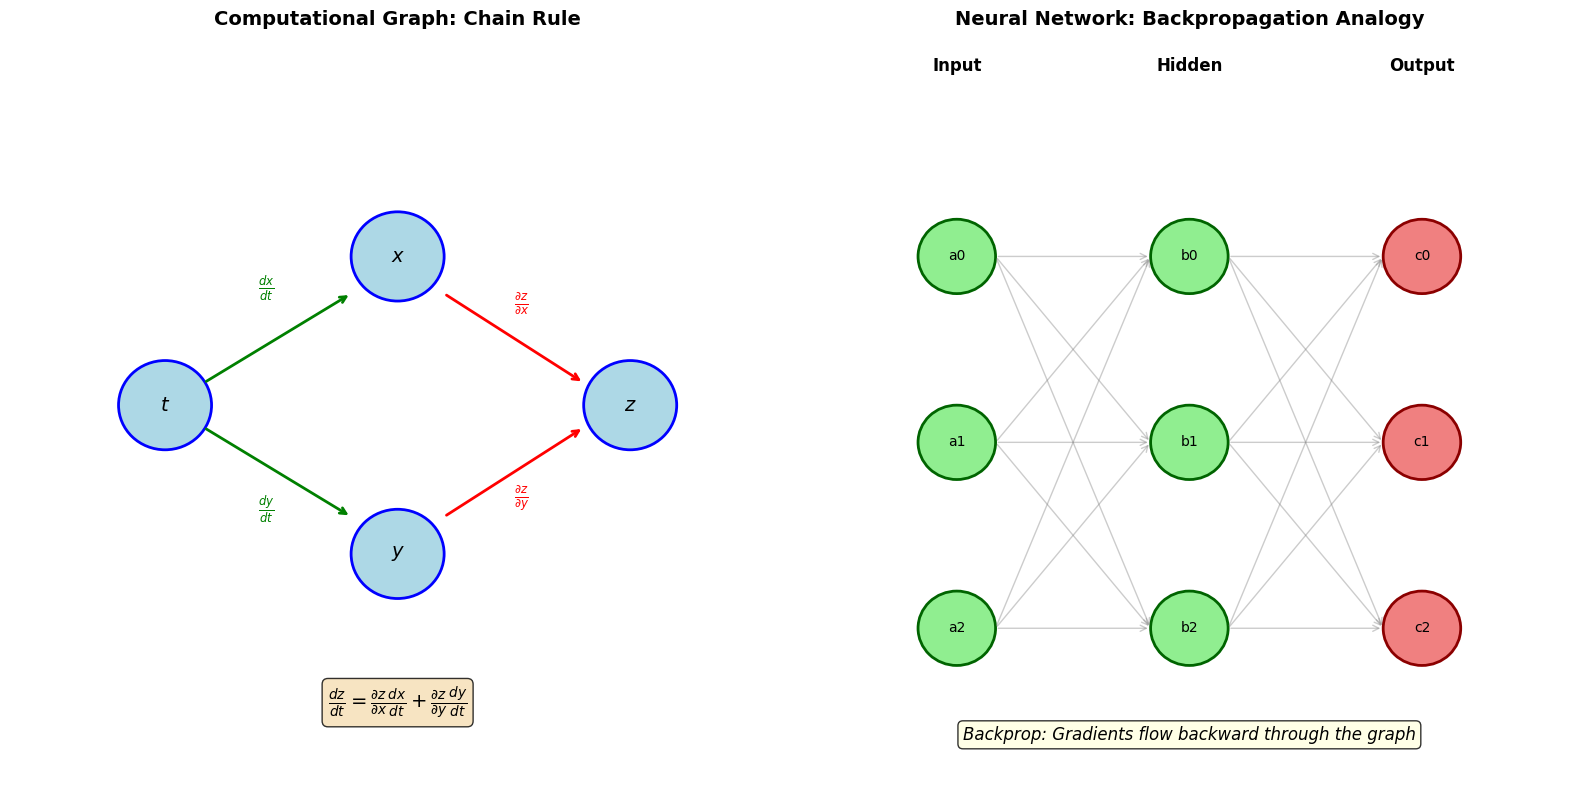


🧮 Chain Rule Numerical Example:
Let z = x² + y², where x = 2t, y = 3t
At t = 1: x = 2, y = 3

Forward pass:
  z = 2² + 3² = 13

Backward pass (chain rule):
  ∂z/∂x = 2x = 4
  ∂z/∂y = 2y = 6
  dx/dt = 2
  dy/dt = 3

  dz/dt = (∂z/∂x)(dx/dt) + (∂z/∂y)(dy/dt)
        = (4)(2) + (6)(3)
        = 8 + 18 = 26

✅ This is exactly how backpropagation works in neural networks!


In [14]:
# ============================================
# Section 12 — Chain Rule & Backpropagation
# ============================================

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_chain_rule():
    """Create a visual computational graph for chain rule."""

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Left: Computational Graph
    ax1 = axes[0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis('off')
    ax1.set_title('Computational Graph: Chain Rule', fontsize=14, fontweight='bold')

    # Nodes
    nodes = {
        't': (2, 5),
        'x': (5, 7),
        'y': (5, 3),
        'z': (8, 5)
    }

    # Draw nodes
    for name, (x, y) in nodes.items():
        circle = plt.Circle((x, y), 0.6, color='lightblue', ec='blue', linewidth=2, zorder=3)
        ax1.add_patch(circle)
        ax1.text(x, y, f'${name}$', ha='center', va='center', fontsize=14, fontweight='bold', zorder=4)

    # Draw edges with labels
    # t -> x
    ax1.annotate('', xy=(4.4, 6.5), xytext=(2.5, 5.3),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax1.text(3.2, 6.5, r'$\frac{dx}{dt}$', fontsize=12, color='green', fontweight='bold')

    # t -> y
    ax1.annotate('', xy=(4.4, 3.5), xytext=(2.5, 4.7),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax1.text(3.2, 3.5, r'$\frac{dy}{dt}$', fontsize=12, color='green', fontweight='bold')

    # x -> z
    ax1.annotate('', xy=(7.4, 5.3), xytext=(5.6, 6.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax1.text(6.5, 6.3, r'$\frac{\partial z}{\partial x}$', fontsize=12, color='red', fontweight='bold')

    # y -> z
    ax1.annotate('', xy=(7.4, 4.7), xytext=(5.6, 3.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax1.text(6.5, 3.7, r'$\frac{\partial z}{\partial y}$', fontsize=12, color='red', fontweight='bold')

    # Formula box
    formula = r'$\frac{dz}{dt} = \frac{\partial z}{\partial x}\frac{dx}{dt} + \frac{\partial z}{\partial y}\frac{dy}{dt}$'
    ax1.text(5, 1, formula, ha='center', va='center', fontsize=14, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Right: Neural Network Analogy
    ax2 = axes[1]
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.axis('off')
    ax2.set_title('Neural Network: Backpropagation Analogy', fontsize=14, fontweight='bold')

    # Simple network layers
    layer_x = [2, 5, 8]
    layer_names = ['Input', 'Hidden', 'Output']

    for i, (lx, name) in enumerate(zip(layer_x, layer_names)):
        ax2.text(lx, 9.5, name, ha='center', fontsize=12, fontweight='bold')
        for j in range(3):
            y = 7 - j * 2.5
            circle = plt.Circle((lx, y), 0.5, color='lightcoral' if i == 2 else 'lightgreen', 
                               ec='darkred' if i == 2 else 'darkgreen', linewidth=2)
            ax2.add_patch(circle)
            ax2.text(lx, y, f'{chr(97+i)}{j}', ha='center', va='center', fontsize=10)

    # Connections
    for i in range(2):
        for j in range(3):
            for k in range(3):
                y1 = 7 - j * 2.5
                y2 = 7 - k * 2.5
                ax2.annotate('', xy=(layer_x[i+1]-0.5, y2), xytext=(layer_x[i]+0.5, y1),
                           arrowprops=dict(arrowstyle='->', color='gray', alpha=0.4, lw=1))

    # Backprop arrows
    ax2.text(5, 0.5, 'Backprop: Gradients flow backward through the graph', 
            ha='center', fontsize=12, style='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Numerical example
    print("\n🧮 Chain Rule Numerical Example:")
    print("="*50)
    print("Let z = x² + y², where x = 2t, y = 3t")
    print("At t = 1: x = 2, y = 3")
    print()
    print("Forward pass:")
    print("  z = 2² + 3² = 13")
    print()
    print("Backward pass (chain rule):")
    print("  ∂z/∂x = 2x = 4")
    print("  ∂z/∂y = 2y = 6")
    print("  dx/dt = 2")
    print("  dy/dt = 3")
    print()
    print("  dz/dt = (∂z/∂x)(dx/dt) + (∂z/∂y)(dy/dt)")
    print("        = (4)(2) + (6)(3)")
    print("        = 8 + 18 = 26")
    print()
    print("✅ This is exactly how backpropagation works in neural networks!")

visualize_chain_rule()


---

# Section 13 — Total Differential Explorer

## The Total Differential

For small changes $dx$ and $dy$:

$$
df = \frac{\partial f}{\partial x} dx + \frac{\partial f}{\partial y} dy
$$

Or in vector form:

$$
df = \nabla f \cdot d\mathbf{x}
$$

## Geometric Meaning

The total differential approximates how much the function changes when we move a small amount $(dx, dy)$ from the current point. It combines the effects of changing each variable independently.

## Connection to AI

In gradient descent, the update rule is:

$$
\mathbf{x}_{new} = \mathbf{x}_{old} - \eta \nabla f
$$

This uses the total differential to estimate how to reduce the function value most efficiently.

> 🎛️ **Interactive Feature**: Adjust $dx$ and $dy$ sliders to see how the total differential predicts the change in $f$.


In [15]:
# ============================================
# Section 13 — Total Differential Explorer
# ============================================

def explore_total_differential(x0=1.0, y0=1.0, dx=0.3, dy=0.2):
    """Visualize total differential and its approximation quality."""

    # Paraboloid: f(x,y) = x² + y²
    z0 = x0**2 + y0**2
    dfdx = 2 * x0
    dfdy = 2 * y0

    # Total differential prediction
    df_approx = dfdx * dx + dfdy * dy

    # Actual change
    z_new = (x0 + dx)**2 + (y0 + dy)**2
    df_actual = z_new - z0

    # Error
    error = abs(df_actual - df_approx)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: 2D visualization
    ax1 = axes[0]

    # Plot point and displacement
    ax1.arrow(x0, y0, dx, dy, head_width=0.08, head_length=0.05, 
             fc='red', ec='red', linewidth=2.5, label=f'dx={dx:.2f}, dy={dy:.2f}')
    ax1.plot(x0, y0, 'bo', markersize=12, label=f'P=({x0:.2f}, {y0:.2f})')
    ax1.plot(x0+dx, y0+dy, 'go', markersize=12, label=f'P+ΔP=({x0+dx:.2f}, {y0+dy:.2f})')

    # Gradient vector
    ax1.arrow(x0, y0, dfdx*0.3, dfdy*0.3, head_width=0.08, head_length=0.05,
             fc='purple', ec='purple', linewidth=2, label='∇f (scaled)')

    # Contours
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2
    cs = ax1.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
    ax1.clabel(cs, inline=True, fontsize=9)

    ax1.set_xlim(-3, 3)
    ax1.set_ylim(-3, 3)
    ax1.set_aspect('equal')
    ax1.set_title('2D: Displacement and Gradient', fontsize=14, fontweight='bold')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Right: Information panel with bar chart
    ax2 = axes[1]
    ax2.axis('off')

    categories = ['Actual Δf', 'Approx df', 'Error']
    values = [df_actual, df_approx, error]
    colors = ['green', 'blue', 'red']

    # Create mini bar chart
    ax2_bar = fig.add_axes([0.58, 0.15, 0.35, 0.6])
    bars = ax2_bar.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax2_bar.set_ylabel('Value', fontsize=12)
    ax2_bar.set_title('Comparison: Actual vs Approximate', fontsize=12, fontweight='bold')
    ax2_bar.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, values):
        ax2_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02*max(values),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Text info
    info = f"""
    📊 TOTAL DIFFERENTIAL ANALYSIS

    Function: f(x,y) = x² + y²

    Point: ({x0:.3f}, {y0:.3f})
    f({x0:.3f}, {y0:.3f}) = {z0:.3f}

    ─────────────────────────────
    Partial Derivatives:
      ∂f/∂x = {dfdx:.3f}
      ∂f/∂y = {dfdy:.3f}

    Displacement:
      dx = {dx:.3f}
      dy = {dy:.3f}

    ─────────────────────────────
    Total Differential:
      df = (∂f/∂x)dx + (∂f/∂y)dy
         = ({dfdx:.3f})({dx:.3f}) + ({dfdy:.3f})({dy:.3f})
         = {dfdx*dx:.3f} + {dfdy*dy:.3f}
         = {df_approx:.3f}

    Actual Change:
      Δf = f({x0+dx:.3f}, {y0+dy:.3f}) - f({x0:.3f}, {y0:.3f})
         = {z_new:.3f} - {z0:.3f}
         = {df_actual:.3f}

    Approximation Error: {error:.6f}

    {'✅ Good approximation!' if error < 0.1 else '⚠️ Large error - use smaller dx, dy'}
    """

    ax2.text(0.05, 0.95, info, transform=ax2.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    plt.tight_layout()
    plt.show()

interact(
    explore_total_differential,
    x0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.0, description='x₀:'),
    y0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.0, description='y₀:'),
    dx=widgets.FloatSlider(min=-1, max=1, step=0.05, value=0.3, description='dx:'),
    dy=widgets.FloatSlider(min=-1, max=1, step=0.05, value=0.2, description='dy:')
)


interactive(children=(FloatSlider(value=1.0, description='x₀:', max=2.0, min=-2.0), FloatSlider(value=1.0, des…

<function __main__.explore_total_differential(x0=1.0, y0=1.0, dx=0.3, dy=0.2)>

---

# Section 14 — Double Integral Visualization

## Definition

The double integral computes the **volume** under a surface $f(x, y)$ over a region $R$:

$$
\iint_R f(x, y) \, dA
$$

## Riemann Sum Interpretation

$$
\iint_R f(x, y) \, dA \approx \sum_{i=1}^n \sum_{j=1}^m f(x_i, y_j) \Delta x \Delta y
$$

As $\Delta x, \Delta y \to 0$, the sum approaches the exact volume.

## Geometric Meaning

- Each term $f(x_i, y_j) \Delta x \Delta y$ is the volume of a small rectangular prism
- The integral sums all these prisms to get the total volume
- If $f(x, y) = 1$, the integral gives the **area** of region $R$

> 📦 **Animation**: Watch as small boxes accumulate to fill the volume under the surface.


In [16]:
# ============================================
# Section 14 — Double Integral Animation
# ============================================

def animate_double_integral():
    """Animate the accumulation of volume under a surface."""

    x = np.linspace(0, 2, 50)
    y = np.linspace(0, 2, 50)
    X, Y = np.meshgrid(x, y)
    Z = X * Y * np.exp(-(X**2 + Y**2)/2)  # A nice bump function

    # True integral (numerical)
    true_integral = integrate.dblquad(lambda y, x: x*y*np.exp(-(x**2+y**2)/2), 0, 2, 0, 2)[0]

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_zlim(0, Z.max() * 1.2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x,y)')
    ax.set_title('Double Integral: Volume Accumulation', fontsize=14, fontweight='bold')

    # Draw surface
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')

    # Animation frames: add bars progressively
    n_frames = 20
    x_steps = np.linspace(0, 2, n_frames+1)
    y_steps = np.linspace(0, 2, n_frames+1)

    bars = []

    def init():
        return bars

    def update(frame):
        # Clear previous bars
        for bar in bars:
            bar.remove()
        bars.clear()

        # Add new bars up to current frame
        xi = frame // int(np.sqrt(n_frames)) + 1
        yj = frame % int(np.sqrt(n_frames)) + 1

        # Actually, let's do a simpler progressive fill
        nx = min(frame + 1, 10)
        ny = min(frame + 1, 10)

        x_sub = np.linspace(0, 2, nx)
        y_sub = np.linspace(0, 2, ny)
        dx = 2 / (nx - 1) if nx > 1 else 2
        dy = 2 / (ny - 1) if ny > 1 else 2

        approx = 0
        for i in range(nx-1):
            for j in range(ny-1):
                xi_val = (x_sub[i] + x_sub[i+1]) / 2
                yj_val = (y_sub[j] + y_sub[j+1]) / 2
                zi = xi_val * yj_val * np.exp(-(xi_val**2 + yj_val**2)/2)
                approx += zi * dx * dy

                # Draw bar
                bar = ax.bar3d(x_sub[i], y_sub[j], 0, dx*0.9, dy*0.9, zi, 
                              color='cyan', alpha=0.6, edgecolor='blue', linewidth=0.5)
                bars.append(bar)

        ax.set_title(f'Double Integral Approximation (nx={nx}, ny={ny})\n'
                    f'Approx = {approx:.4f} | True = {true_integral:.4f} | Error = {abs(approx-true_integral):.4f}',
                    fontsize=12, fontweight='bold')

        return bars

    anim = FuncAnimation(fig, update, frames=10, init_func=init, 
                        blit=False, interval=800, repeat=True)

    plt.close()
    display(HTML(anim.to_jshtml()))

    print(f"\n📦 Double Integral Analysis:")
    print(f"   True value (numerical): {true_integral:.6f}")
    print(f"   Function: f(x,y) = xy·exp(-(x²+y²)/2)")
    print(f"   Region: [0,2] × [0,2]")
    print(f"   As grid refines, approximation → true value")

animate_double_integral()



📦 Double Integral Analysis:
   True value (numerical): 0.747645
   Function: f(x,y) = xy·exp(-(x²+y²)/2)
   Region: [0,2] × [0,2]
   As grid refines, approximation → true value


---

# Section 15 — Triple Integral Concept

## Definition

The triple integral extends integration to three dimensions:

$$
\iiint_V f(x, y, z) \, dV
$$

## Physical Interpretations

| Context | $f(x,y,z)$ | Integral Represents |
|---------|-----------|---------------------|
| **Mass** | Density $\rho(x,y,z)$ | Total mass of object |
| **Charge** | Charge density | Total charge |
| **Probability** | PDF $p(x,y,z)$ | Probability in volume $V$ |
| **Average** | Any function | Average value over volume |

## Volume Element

$$
dV = dx \, dy \, dz
$$

In other coordinate systems:
- **Cylindrical**: $dV = r \, dr \, d\theta \, dz$
- **Spherical**: $dV = \rho^2 \sin\phi \, d\rho \, d\phi \, d\theta$

> 🎲 **Concept**: Triple integrals accumulate "stuff" (mass, probability, etc.) throughout a 3D region. In machine learning, this concept extends to high-dimensional probability distributions.


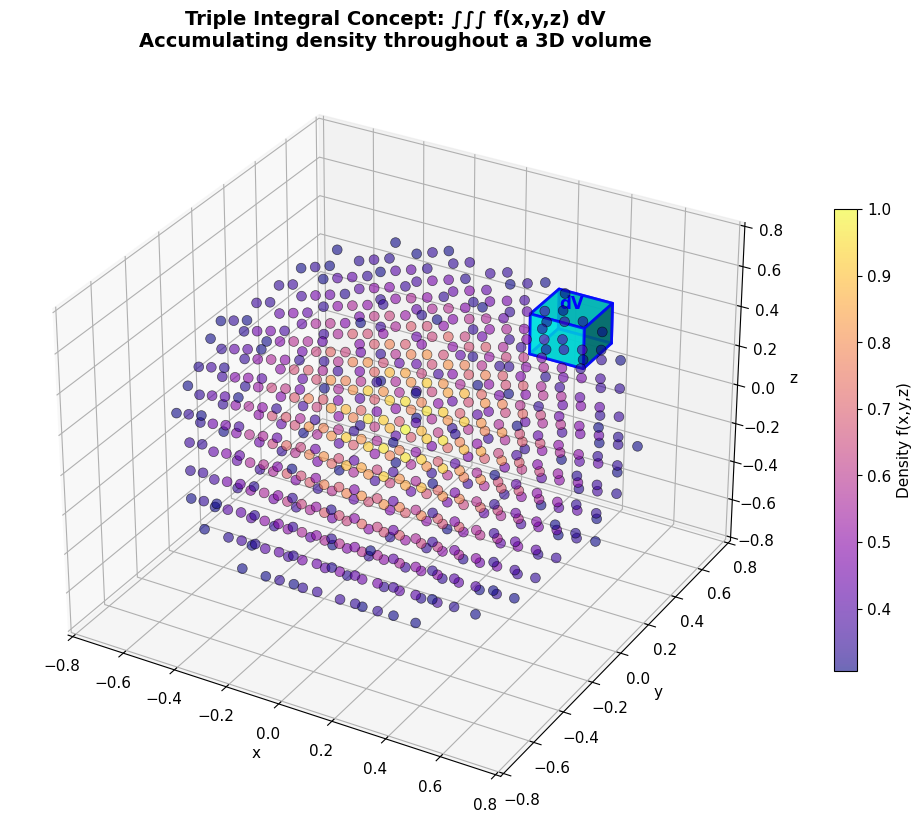


🎲 Triple Integral Concept:
   Function: f(x,y,z) = exp(-(x²+y²+z²)/0.5)
   Volume: [-1,1] × [-1,1] × [-1,1]
   Grid: 15×15×15 = 3375 points
   Volume element dV = 0.002915
   Approximate integral: 1.788229

   Physical interpretation:
   • If f = density, integral = total mass
   • If f = probability density, integral = total probability
   • In ML: high-dimensional integrals for expectations


In [17]:
# ============================================
# Section 15 — Triple Integral Concept
# ============================================

def visualize_triple_integral():
    """Create a conceptual 3D visualization of triple integral."""

    fig = plt.figure(figsize=(14, 10))

    # Create a 3D grid of points
    n = 15
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    z = np.linspace(-1, 1, n)
    X, Y, Z = np.meshgrid(x, y, z)

    # Density function: Gaussian blob
    density = np.exp(-(X**2 + Y**2 + Z**2) / 0.5)

    # Sample points for visualization (subset)
    mask = density > 0.3
    x_vis = X[mask]
    y_vis = Y[mask]
    z_vis = Z[mask]
    c_vis = density[mask]

    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with color = density
    scatter = ax.scatter(x_vis, y_vis, z_vis, c=c_vis, cmap='plasma', 
                        s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

    # Draw bounding box
    from itertools import product
    for s, e in zip(product([-1, 1], [-1, 1], [-1, 1]), 
                    product([-1, 1], [-1, 1], [-1, 1])):
        if sum(1 for a, b in zip(s, e) if a != b) == 1:
            ax.plot3D(*zip(s, e), color='gray', alpha=0.3, linewidth=1)

    # Volume element visualization
    # Draw one small cube
    cube_x, cube_y, cube_z = 0.3, 0.3, 0.3
    dx = 0.2
    ax.bar3d(cube_x, cube_y, cube_z, dx, dx, dx, 
            color='cyan', alpha=0.8, edgecolor='blue', linewidth=2)
    ax.text(cube_x+dx/2, cube_y+dx/2, cube_z+dx, 'dV', fontsize=12, 
           color='blue', fontweight='bold', ha='center')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('Triple Integral Concept: ∫∫∫ f(x,y,z) dV\n'
                'Accumulating density throughout a 3D volume', 
                fontsize=14, fontweight='bold')

    plt.colorbar(scatter, ax=ax, label='Density f(x,y,z)', shrink=0.6)
    plt.show()

    # Numerical approximation
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]
    dV = dx * dy * dz
    approx_integral = np.sum(density) * dV

    # Analytical for Gaussian
    # ∫∫∫ exp(-(x²+y²+z²)/0.5) dV = (π·0.5)^(3/2) over infinite domain
    # Over [-1,1]³, we approximate numerically

    print(f"\n🎲 Triple Integral Concept:")
    print(f"   Function: f(x,y,z) = exp(-(x²+y²+z²)/0.5)")
    print(f"   Volume: [-1,1] × [-1,1] × [-1,1]")
    print(f"   Grid: {n}×{n}×{n} = {n**3} points")
    print(f"   Volume element dV = {dV:.6f}")
    print(f"   Approximate integral: {approx_integral:.6f}")
    print(f"\n   Physical interpretation:")
    print(f"   • If f = density, integral = total mass")
    print(f"   • If f = probability density, integral = total probability")
    print(f"   • In ML: high-dimensional integrals for expectations")

visualize_triple_integral()


---

# Section 16 — Jacobian Matrix Preview

## Definition

The **Jacobian matrix** of a transformation $\mathbf{F}: \mathbb{R}^n \rightarrow \mathbb{R}^m$ is:

$$
J = \begin{bmatrix} 
\frac{\partial F_1}{\partial x_1} & \cdots & \frac{\partial F_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial F_m}{\partial x_1} & \cdots & \frac{\partial F_m}{\partial x_n}
\end{bmatrix}
$$

## Geometric Interpretation

The Jacobian describes how a transformation **stretches, rotates, and warps** local regions:

$$
d\mathbf{y} = J \, d\mathbf{x}
$$

- **Determinant** $|J|$: Local area/volume scaling factor
- **Singular values**: Principal stretching directions and amounts

## Connection to AI

In neural networks, the Jacobian maps changes in **input** to changes in **output** — essential for understanding network sensitivity and adversarial examples.

> 🔄 **Interactive Feature**: Watch how a square grid warps under different transformations, with the Jacobian revealing local stretching.


In [ ]:
# ============================================
# Section 16 — Jacobian Matrix Visualization
# ============================================

def visualize_jacobian(transform='Rotation', angle=30, scale_x=1.5, scale_y=0.8):
    """Visualize Jacobian through coordinate transformations."""

    theta = np.deg2rad(angle)

    # Create grid
    n = 15
    x = np.linspace(-2, 2, n)
    y = np.linspace(-2, 2, n)
    X, Y = np.meshgrid(x, y)

    # Original grid points
    points = np.array([X.flatten(), Y.flatten()])

    # Apply transformation
    if transform == 'Rotation':
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta), np.cos(theta)]])
        transformed = R @ points
        J = R
    elif transform == 'Scaling':
        S = np.array([[scale_x, 0], [0, scale_y]])
        transformed = S @ points
        J = S
    elif transform == 'Shear':
        Sh = np.array([[1, scale_x-1], [0, 1]])
        transformed = Sh @ points
        J = Sh
    elif transform == 'Polar-like':
        r = np.sqrt(points[0]**2 + points[1]**2)
        phi = np.arctan2(points[1], points[0])
        transformed = np.array([r * np.cos(phi + 0.3*r), r * np.sin(phi + 0.3*r)])
        # Jacobian is position-dependent for nonlinear transforms
        J = np.array([[1, 0], [0, 1]])  # Placeholder

    X_new = transformed[0].reshape(n, n)
    Y_new = transformed[1].reshape(n, n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Original grid
    for i in range(n):
        axes[0].plot(X[i, :], Y[i, :], 'b-', alpha=0.5, linewidth=1)
        axes[0].plot(X[:, i], Y[:, i], 'b-', alpha=0.5, linewidth=1)
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].set_title('Original Grid', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].grid(True, alpha=0.3)

    # Highlight a unit square
    square = plt.Rectangle((0.5, 0.5), 1, 1, fill=False, edgecolor='red', linewidth=2)
    axes[0].add_patch(square)
    axes[0].text(1, 1, 'Unit Square', color='red', fontsize=10, ha='center')

    # Transformed grid
    for i in range(n):
        axes[1].plot(X_new[i, :], Y_new[i, :], 'r-', alpha=0.5, linewidth=1)
        axes[1].plot(X_new[:, i], Y_new[:, i], 'r-', alpha=0.5, linewidth=1)
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].set_title(f'Transformed Grid: {transform}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('x\'')
    axes[1].set_ylabel('y\'')
    axes[1].grid(True, alpha=0.3)

    # Jacobian info
    if transform != 'Polar-like':
        det = np.linalg.det(J)
        print(f"\n🔄 Jacobian Analysis: {transform}")
        print(f"   J = [[{J[0,0]:.3f}, {J[0,1]:.3f}],")
        print(f"        [{J[1,0]:.3f}, {J[1,1]:.3f}]]")
        print(f"   det(J) = {det:.3f}")
        print(f"   Area scaling: {abs(det):.3f}x")
        if det > 0:
            print(f"   Orientation: PRESERVED")
        else:
            print(f"   Orientation: REVERSED")

    plt.tight_layout()
    plt.show()

interact(
    visualize_jacobian,
    transform=widgets.Dropdown(
        options=['Rotation', 'Scaling', 'Shear', 'Polar-like'],
        value='Rotation',
        description='Transform:'
    ),
    angle=widgets.FloatSlider(min=0, max=360, step=5, value=30, description='Angle (°):'),
    scale_x=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1.5, description='Scale X:'),
    scale_y=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=0.8, description='Scale Y:')
)


interactive(children=(Dropdown(description='Transform:', options=('Rotation', 'Scaling', 'Shear', 'Polar-like'…

<function __main__.visualize_jacobian(transform='Rotation', angle=30, scale_x=1.5, scale_y=0.8)>

---

# Section 17 — Hessian Matrix Preview

## Definition

The **Hessian matrix** contains all second-order partial derivatives:

$$
H = \begin{bmatrix} 
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{bmatrix}
$$

## Critical Point Classification

Using eigenvalues $\lambda_1, \lambda_2$ of $H$:

| $\lambda_1$ | $\lambda_2$ | Classification | Surface Shape |
|-------------|-------------|----------------|---------------|
| $> 0$ | $> 0$ | **Local Minimum** | Bowl (convex) |
| $< 0$ | $< 0$ | **Local Maximum** | Dome (concave) |
| Mixed signs | | **Saddle Point** | Saddle |
| $= 0$ | Any | **Degenerate** | Flat direction |

## Why Hessians Matter in Optimization

- **Curvature information**: Tells us how "flat" or "steep" the landscape is
- **Newton's method**: Uses $H^{-1}$ for faster convergence
- **Saddle points**: Deep learning landscapes are full of them — Hessians help detect and escape

> 🎢 **Analogy**: The Hessian is like a "curvature radar" — it tells you whether you're in a valley, on a hill, or at a mountain pass.


In [19]:
# ============================================
# Section 17 — Hessian Matrix & Curvature
# ============================================

def analyze_hessian(surface_type='Convex'):
    """Visualize Hessian and curvature for different surfaces."""

    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)

    surfaces = {
        'Convex (Minimum)': {
            'Z': X**2 + Y**2,
            'H': [[2, 0], [0, 2]],
            'desc': 'Bowl shape - positive definite Hessian'
        },
        'Concave (Maximum)': {
            'Z': -(X**2 + Y**2),
            'H': [[-2, 0], [0, -2]],
            'desc': 'Dome shape - negative definite Hessian'
        },
        'Saddle Point': {
            'Z': X**2 - Y**2,
            'H': [[2, 0], [0, -2]],
            'desc': 'Saddle shape - indefinite Hessian'
        },
        'Twisted Saddle': {
            'Z': X*Y,
            'H': [[0, 1], [1, 0]],
            'desc': 'Rotated saddle - mixed derivatives'
        }
    }

    s = surfaces[surface_type]
    Z = s['Z']
    H = np.array(s['H'])

    # Eigenvalues
    eigenvalues, eigenvectors = np.linalg.eig(H)

    fig = plt.figure(figsize=(16, 10))

    # 3D surface
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.set_title(f'{surface_type}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')

    # Contour with principal curvature directions
    ax2 = fig.add_subplot(2, 2, 2)
    cs = ax2.contour(X, Y, Z, levels=15, cmap='viridis')
    ax2.clabel(cs, inline=True, fontsize=9)

    # Draw eigenvectors at origin
    origin = [0, 0]
    for i, (ev, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
        color = 'green' if ev > 0 else 'red' if ev < 0 else 'blue'
        scale = 1.5
        ax2.arrow(origin[0], origin[1], vec[0]*scale, vec[1]*scale,
                 head_width=0.15, head_length=0.1, fc=color, ec=color, linewidth=2.5,
                 label=f'λ{i+1}={ev:.1f}')

    ax2.set_title('Principal Curvature Directions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_aspect('equal')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Hessian matrix display
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.axis('off')

    hessian_text = f"""
    HESSIAN MATRIX ANALYSIS

    Surface: {surface_type}
    {s['desc']}

    ─────────────────────────
    Hessian Matrix H:

        ┌                    ┐
        │  {H[0,0]:6.2f}    {H[0,1]:6.2f}  │
        │                    │
        │  {H[1,0]:6.2f}    {H[1,1]:6.2f}  │
        └                    ┘

    ─────────────────────────
    Eigenvalues:
      λ₁ = {eigenvalues[0]:.3f}
      λ₂ = {eigenvalues[1]:.3f}

    ─────────────────────────
    Classification:
    """

    if all(eigenvalues > 0):
        classification = "POSITIVE DEFINITE\n→ Local MINIMUM"
    elif all(eigenvalues < 0):
        classification = "NEGATIVE DEFINITE\n→ Local MAXIMUM"
    elif eigenvalues[0] * eigenvalues[1] < 0:
        classification = "INDEFINITE\n→ SADDLE POINT"
    else:
        classification = "DEGENERATE\n→ Need higher-order analysis"

    hessian_text += f"    {classification}"
    hessian_text += f""""

    ax3.text(0.1, 0.5, hessian_text, transform=ax3.transAxes, fontsize=11,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Curvature visualization
    ax4 = fig.add_subplot(2, 2, 4)

    # Plot cross-sections
    t = np.linspace(-2, 2, 100)
    for i, (ev, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
        # Cross-section in eigenvector direction
        z_cross = 0.5 * ev * t**2
        ax4.plot(t, z_cross, linewidth=2.5, 
                label=f'Direction v{i+1}: λ={ev:.1f}',
                color='green' if ev > 0 else 'red' if ev < 0 else 'blue')

    ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax4.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax4.set_title('Curvature in Principal Directions', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Distance from critical point')
    ax4.set_ylabel('f (cross-section)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n🎢 Hessian Analysis: {surface_type}")
    print(f"   Eigenvalues: {eigenvalues}")
    print(f"   Determinant: {np.linalg.det(H):.3f}")
    print(f"   Trace: {np.trace(H):.3f}")

interact(
    analyze_hessian,
    surface_type=widgets.Dropdown(
        options=['Convex (Minimum)', 'Concave (Maximum)', 'Saddle Point', 'Twisted Saddle'],
        value='Convex (Minimum)',
        description='Surface:'
    )
)


_IncompleteInputError: incomplete input (3056789317.py, line 111)

---

# Section 18 — Optimization Landscape

## Critical Points in Optimization

An optimization landscape is defined by a **loss function** $L(\theta_1, \theta_2)$. The goal is to find parameters that minimize this function.

## Types of Critical Points

$$
\nabla L = \mathbf{0}
$$

1. **Local Minimum**: $\nabla L = 0$, $H$ positive definite — **GOOD**
2. **Local Maximum**: $\nabla L = 0$, $H$ negative definite — **BAD**
3. **Saddle Point**: $\nabla L = 0$, $H$ indefinite — **TRAP**
4. **Global Minimum**: The lowest point overall — **OPTIMAL**

## Optimization Challenges

- **Non-convexity**: Most deep learning landscapes have many local minima
- **Saddle points**: High-dimensional spaces have exponentially many saddles
- **Plateaus**: Regions with near-zero gradient slow convergence
- **Cliffs**: Very steep regions cause gradient explosion

> 🏔️ **Analogy**: Optimizing a neural network is like hiking in a mountain range at night with a flashlight (gradient) — you follow the slope, but you might get stuck in a small valley or on a ridge.


In [20]:
# ============================================
# Section 18 — Optimization Landscape Explorer
# ============================================

def explore_optimization_landscape(landscape='Bowl'):
    """Explore different optimization landscapes."""

    x = np.linspace(-3, 3, 150)
    y = np.linspace(-3, 3, 150)
    X, Y = np.meshgrid(x, y)

    landscapes = {
        'Bowl (Convex)': {
            'Z': X**2 + Y**2,
            'critical': [(0, 0)],
            'types': ['Global Minimum'],
            'desc': 'Ideal: One global minimum, easy optimization'
        },
        'Saddle': {
            'Z': X**2 - Y**2,
            'critical': [(0, 0)],
            'types': ['Saddle Point'],
            'desc': 'Trap: Gradient is zero but not a minimum'
        },
        'Double Well': {
            'Z': (X**2 - 1)**2 + Y**2,
            'critical': [(-1, 0), (1, 0), (0, 0)],
            'types': ['Local Min', 'Local Min', 'Saddle'],
            'desc': 'Two local minima separated by a saddle'
        },
        'Ripple': {
            'Z': np.sin(3*X) * np.cos(3*Y) + 0.1*(X**2 + Y**2),
            'critical': [(0, 0)],
            'types': ['Approximate Min'],
            'desc': 'Many local minima - non-convex landscape'
        },
        'Rosenbrock': {
            'Z': (1 - X)**2 + 100*(Y - X**2)**2,
            'critical': [(1, 1)],
            'types': ['Global Minimum'],
            'desc': 'Classic test: Narrow curved valley'
        }
    }

    l = landscapes[landscape]
    Z = l['Z']

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'contour'}]],
        subplot_titles=('3D Landscape', 'Contour Map with Critical Points'),
        column_widths=[0.6, 0.4]
    )

    # 3D Surface
    fig.add_trace(go.Surface(
        z=Z, x=X, y=Y,
        colorscale='Viridis',
        showscale=False,
        contours=dict(z=dict(show=True, usecolormap=True, project_z=True))
    ), row=1, col=1)

    # Mark critical points on 3D surface
    for (cx, cy), ctype in zip(l['critical'], l['types']):
        cz = (1 - cx)**2 + 100*(cy - cx**2)**2 if landscape == 'Rosenbrock' else              (cx**2 - 1)**2 + cy**2 if landscape == 'Double Well' else              cx**2 - cy**2 if landscape == 'Saddle' else              np.sin(3*cx)*np.cos(3*cy) + 0.1*(cx**2+cy**2) if landscape == 'Ripple' else              cx**2 + cy**2

        color = 'red' if 'Min' in ctype else 'yellow' if 'Saddle' in ctype else 'orange'
        fig.add_trace(go.Scatter3d(
            x=[cx], y=[cy], z=[cz],
            mode='markers',
            marker=dict(size=8, color=color),
            name=ctype
        ), row=1, col=1)

    # Contour
    fig.add_trace(go.Contour(
        z=Z, x=x, y=y,
        colorscale='Viridis',
        contours=dict(showlabels=True),
        colorbar=dict(title='Loss', thickness=15, x=0.45)
    ), row=1, col=2)

    # Mark critical points on contour
    for (cx, cy), ctype in zip(l['critical'], l['types']):
        color = 'red' if 'Min' in ctype else 'yellow' if 'Saddle' in ctype else 'orange'
        fig.add_trace(go.Scatter(
            x=[cx], y=[cy],
            mode='markers',
            marker=dict(size=12, color=color, symbol='x', line=dict(width=2, color='black')),
            name=ctype
        ), row=1, col=2)

    fig.update_layout(
        title=dict(
            text=f'<b>{landscape}</b><br><span style="font-size:13px">{l["desc"]}</span>',
            x=0.5, font=dict(size=16)
        ),
        height=600,
        width=1200,
        scene=dict(
            xaxis_title='θ₁', yaxis_title='θ₂', zaxis_title='Loss',
            aspectratio=dict(x=1, y=1, z=0.7)
        )
    )

    fig.show()

    print(f"\n🏔️ Optimization Landscape: {landscape}")
    print(f"   Description: {l['desc']}")
    print(f"   Critical points: {len(l['critical'])}")
    for (cx, cy), ctype in zip(l['critical'], l['types']):
        print(f"   • ({cx}, {cy}): {ctype}")

interact(
    explore_optimization_landscape,
    landscape=widgets.Dropdown(
        options=['Bowl (Convex)', 'Saddle', 'Double Well', 'Ripple', 'Rosenbrock'],
        value='Bowl (Convex)',
        description='Landscape:'
    )
)


interactive(children=(Dropdown(description='Landscape:', options=('Bowl (Convex)', 'Saddle', 'Double Well', 'R…

<function __main__.explore_optimization_landscape(landscape='Bowl')>

---

# Section 19 — Gradient Descent Animation

## The Algorithm

Gradient descent updates parameters to minimize a loss function:

$$
\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)
$$

Where:
- $\theta_t$: Parameters at step $t$
- $\eta$: Learning rate (step size)
- $\nabla L$: Gradient of loss with respect to parameters

## Convergence Behavior

| Learning Rate | Behavior |
|--------------|----------|
| **Too small** | Slow convergence, many iterations |
| **Just right** | Smooth, steady convergence |
| **Too large** | Oscillation, divergence |
| **Adaptive** | Adjusts per parameter (Adam, RMSprop) |

> 🎬 **Animation**: Watch gradient descent navigate different loss landscapes. Adjust the learning rate to see convergence, oscillation, and divergence.


In [21]:
# ============================================
# Section 19 — Gradient Descent Animation
# ============================================

def animate_gradient_descent(landscape='Bowl', lr=0.1, n_steps=30, start_x=2.0, start_y=2.0):
    """Animate gradient descent on various loss surfaces."""

    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)

    if landscape == 'Bowl':
        Z = X**2 + Y**2
        def grad(px, py):
            return np.array([2*px, 2*py])
    elif landscape == 'Saddle':
        Z = X**2 - Y**2
        def grad(px, py):
            return np.array([2*px, -2*py])
    elif landscape == 'Ripple':
        Z = np.sin(2*X) * np.cos(2*Y) + 0.05*(X**2 + Y**2)
        def grad(px, py):
            return np.array([2*np.cos(2*px)*np.cos(2*py) + 0.1*px,
                           -2*np.sin(2*px)*np.sin(2*py) + 0.1*py])
    elif landscape == 'Rosenbrock':
        Z = (1-X)**2 + 100*(Y-X**2)**2
        def grad(px, py):
            return np.array([-2*(1-px) - 400*px*(py-px**2), 200*(py-px**2)])

    # Run gradient descent
    path = [(start_x, start_y)]
    pos = np.array([start_x, start_y])

    for _ in range(n_steps):
        g = grad(pos[0], pos[1])
        pos = pos - lr * g
        path.append(tuple(pos))

        # Stop if diverging
        if np.linalg.norm(pos) > 10:
            break

    path = np.array(path)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Contour
    cs = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.7)
    ax.clabel(cs, inline=True, fontsize=9)

    # Path
    ax.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, linewidth=2, label='GD Path')
    ax.plot(path[0, 0], path[0, 1], 'go', markersize=15, label='Start', zorder=5)
    ax.plot(path[-1, 0], path[-1, 1], 'b*', markersize=15, label='End', zorder=5)

    # Arrows showing direction
    for i in range(min(len(path)-1, 20)):
        dx = path[i+1, 0] - path[i, 0]
        dy = path[i+1, 1] - path[i, 1]
        if np.sqrt(dx**2 + dy**2) > 0.01:
            ax.arrow(path[i, 0], path[i, 1], dx*0.7, dy*0.7,
                    head_width=0.08, head_length=0.05, fc='red', ec='red', alpha=0.6)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(f'Gradient Descent on {landscape}\n'
                f'LR={lr}, Steps={len(path)-1}, Start=({start_x},{start_y})',
                fontsize=14, fontweight='bold')
    ax.set_xlabel('θ₁')
    ax.set_ylabel('θ₂')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Loss trajectory
    losses = []
    for px, py in path:
        if landscape == 'Bowl':
            losses.append(px**2 + py**2)
        elif landscape == 'Saddle':
            losses.append(px**2 - py**2)
        elif landscape == 'Ripple':
            losses.append(np.sin(2*px)*np.cos(2*py) + 0.05*(px**2+py**2))
        elif landscape == 'Rosenbrock':
            losses.append((1-px)**2 + 100*(py-px**2)**2)

    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.plot(losses, 'b-', linewidth=2, marker='o', markersize=4)
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Loss vs. Iteration', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log' if max(losses) > 10*min(losses) else 'linear')
    plt.show()

    print(f"\n📉 Gradient Descent Results:")
    print(f"   Landscape: {landscape}")
    print(f"   Learning rate: {lr}")
    print(f"   Steps: {len(path)-1}")
    print(f"   Initial loss: {losses[0]:.4f}")
    print(f"   Final loss: {losses[-1]:.4f}")
    print(f"   Final position: ({path[-1, 0]:.4f}, {path[-1, 1]:.4f})")

    if losses[-1] > losses[0] * 0.9 and len(path) > 5:
        print(f"   ⚠️ Warning: Slow convergence or divergence")
    elif losses[-1] < 0.01:
        print(f"   ✅ Good convergence!")

interact(
    animate_gradient_descent,
    landscape=widgets.Dropdown(
        options=['Bowl', 'Saddle', 'Ripple', 'Rosenbrock'],
        value='Bowl',
        description='Landscape:'
    ),
    lr=widgets.FloatLogSlider(min=-3, max=0, step=0.1, value=0.1, description='Learning Rate:'),
    n_steps=widgets.IntSlider(min=5, max=100, step=5, value=30, description='Steps:'),
    start_x=widgets.FloatSlider(min=-2.5, max=2.5, step=0.1, value=2.0, description='Start x:'),
    start_y=widgets.FloatSlider(min=-2.5, max=2.5, step=0.1, value=2.0, description='Start y:')
)


interactive(children=(Dropdown(description='Landscape:', options=('Bowl', 'Saddle', 'Ripple', 'Rosenbrock'), v…

<function __main__.animate_gradient_descent(landscape='Bowl', lr=0.1, n_steps=30, start_x=2.0, start_y=2.0)>

---

# Section 20 — Loss Surface Explorer

## Common ML Loss Landscapes

### 1. Linear Regression Loss (MSE)

$$
L(\theta) = \frac{1}{n} \sum_{i=1}^n (y_i - \theta^T x_i)^2
$$

**Properties**: Convex, bowl-shaped, single global minimum

### 2. Logistic Regression Loss (Cross-Entropy)

$$
L(\theta) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]
$$

**Properties**: Convex, sigmoid-shaped cross-sections

### 3. Non-Convex Loss (Neural Network)

$$
L(\theta) = \text{complex composition of nonlinear activations}
$$

**Properties**: Many local minima, saddle points, plateaus

> 🔬 **Insight**: The loss landscape of a neural network with millions of parameters is a high-dimensional surface that we can only visualize in 2D slices. These slices reveal the complexity that optimizers must navigate.


In [22]:
# ============================================
# Section 20 — ML Loss Surface Explorer
# ============================================

def explore_ml_loss(loss_type='MSE (Linear)', noise=0.1):
    """Visualize common machine learning loss surfaces."""

    # Generate synthetic data
    np.random.seed(42)
    n_samples = 100
    x_data = np.random.randn(n_samples)
    y_true = 2 * x_data + 1 + noise * np.random.randn(n_samples)

    # Parameter grid
    theta0 = np.linspace(-1, 4, 100)  # intercept
    theta1 = np.linspace(-1, 4, 100)  # slope
    T0, T1 = np.meshgrid(theta0, theta1)

    if loss_type == 'MSE (Linear)':
        # MSE loss surface
        Z = np.zeros_like(T0)
        for i in range(len(theta0)):
            for j in range(len(theta1)):
                y_pred = T1[j, i] * x_data + T0[j, i]
                Z[j, i] = np.mean((y_true - y_pred)**2)

        # Optimal parameters (analytical)
        theta1_opt = np.cov(x_data, y_true)[0,1] / np.var(x_data)
        theta0_opt = np.mean(y_true) - theta1_opt * np.mean(x_data)

    elif loss_type == 'Logistic (Cross-Entropy)':
        # Binary classification data
        y_binary = (y_true > np.median(y_true)).astype(float)
        Z = np.zeros_like(T0)
        for i in range(len(theta0)):
            for j in range(len(theta1)):
                z = T1[j, i] * x_data + T0[j, i]
                y_pred = 1 / (1 + np.exp(-z))
                # Clip for numerical stability
                y_pred = np.clip(y_pred, 1e-10, 1-1e-10)
                Z[j, i] = -np.mean(y_binary * np.log(y_pred) + (1-y_binary) * np.log(1-y_pred))

        theta0_opt = theta1_opt = None  # No closed form

    elif loss_type == 'Non-Convex (Neural)':
        # Simulate a non-convex landscape
        Z = (T0 - 1.5)**2 + (T1 - 2)**2 + 2*np.sin(3*T0) * np.cos(3*T1)
        theta0_opt = theta1_opt = None

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'contour'}]],
        subplot_titles=(f'{loss_type} Loss Surface', 'Contour Map'),
        column_widths=[0.6, 0.4]
    )

    # 3D Surface
    fig.add_trace(go.Surface(
        z=Z, x=T0, y=T1,
        colorscale='Plasma',
        showscale=False,
        contours=dict(z=dict(show=True, usecolormap=True, project_z=True))
    ), row=1, col=1)

    # Mark optimal point if known
    if theta0_opt is not None:
        fig.add_trace(go.Scatter3d(
            x=[theta0_opt], y=[theta1_opt], z=[np.min(Z)],
            mode='markers',
            marker=dict(size=10, color='green', symbol='diamond'),
            name='Optimal'
        ), row=1, col=1)

    # Contour
    fig.add_trace(go.Contour(
        z=Z, x=theta0, y=theta1,
        colorscale='Plasma',
        contours=dict(showlabels=True),
        colorbar=dict(title='Loss', thickness=15, x=0.45)
    ), row=1, col=2)

    if theta0_opt is not None:
        fig.add_trace(go.Scatter(
            x=[theta0_opt], y=[theta1_opt],
            mode='markers',
            marker=dict(size=12, color='green', symbol='diamond', line=dict(width=2, color='black')),
            name='Optimal'
        ), row=1, col=2)

    fig.update_layout(
        title=dict(
            text=f'<b>{loss_type}</b><br><span style="font-size:13px">Loss Landscape Visualization</span>',
            x=0.5, font=dict(size=16)
        ),
        height=600,
        width=1200,
        scene=dict(
            xaxis_title='θ₀ (intercept/bias)',
            yaxis_title='θ₁ (slope/weight)',
            zaxis_title='Loss',
            aspectratio=dict(x=1, y=1, z=0.7)
        )
    )

    fig.show()

    print(f"\n🔬 ML Loss Surface: {loss_type}")
    print(f"   Data samples: {n_samples}")
    print(f"   Noise level: {noise}")
    if theta0_opt is not None:
        print(f"   Optimal θ₀: {theta0_opt:.3f}")
        print(f"   Optimal θ₁: {theta1_opt:.3f}")
        print(f"   Minimum loss: {np.min(Z):.4f}")
    print(f"   Loss range: [{np.min(Z):.4f}, {np.max(Z):.4f}]")

    if loss_type == 'MSE (Linear)':
        print(f"\n   ✅ Convex: Guaranteed global minimum")
    elif loss_type == 'Logistic (Cross-Entropy)':
        print(f"   ✅ Convex: No local minima (for linear model)")
    elif loss_type == 'Non-Convex (Neural)':
        print(f"   ⚠️ Non-convex: Multiple local minima possible")

interact(
    explore_ml_loss,
    loss_type=widgets.Dropdown(
        options=['MSE (Linear)', 'Logistic (Cross-Entropy)', 'Non-Convex (Neural)'],
        value='MSE (Linear)',
        description='Loss Type:'
    ),
    noise=widgets.FloatSlider(min=0, max=1, step=0.05, value=0.1, description='Noise:')
)


interactive(children=(Dropdown(description='Loss Type:', options=('MSE (Linear)', 'Logistic (Cross-Entropy)', …

<function __main__.explore_ml_loss(loss_type='MSE (Linear)', noise=0.1)>

---

# Section 21 — Neural Network Loss Surface

## Simplified Neural Network

Consider a 2-layer network with one hidden unit:

$$
\hat{y} = \sigma(w_2 \sigma(w_1 x + b_1) + b_2)
$$

The loss landscape over $(w_1, w_2)$ reveals:
- **Symmetry**: Swapping signs of weights can give equivalent solutions
- **Saddle points**: Abundant in high dimensions
- **Flat regions**: Where gradients vanish (sigmoid saturation)

## Why Deep Learning Uses Gradients

1. **Scalability**: Gradients work in millions of dimensions
2. **Differentiability**: Modern frameworks auto-differentiate
3. **Stochasticity**: SGD noise helps escape local minima
4. **Momentum**: Accumulated gradients accelerate convergence

> 🧠 **Key Insight**: Despite the non-convexity, gradient-based methods work remarkably well in practice because:
> - Most local minima are nearly as good as the global minimum
> - Saddle points are more problematic than local minima in high dimensions
> - The probability of hitting a bad local minimum decreases with dimensionality


In [23]:
# ============================================
# Section 21 — Neural Network Loss Surface
# ============================================

def visualize_nn_loss_surface():
    """Create a simplified neural network loss landscape."""

    # Simple 1D regression problem
    np.random.seed(42)
    x_data = np.linspace(-2, 2, 50)
    y_true = np.sin(x_data) + 0.1 * np.random.randn(50)

    # 2-layer network: y = w2 * tanh(w1 * x)
    # Loss landscape over (w1, w2)
    w1 = np.linspace(-3, 3, 100)
    w2 = np.linspace(-3, 3, 100)
    W1, W2 = np.meshgrid(w1, w2)

    Z = np.zeros_like(W1)
    for i in range(len(w1)):
        for j in range(len(w2)):
            y_pred = W2[j, i] * np.tanh(W1[j, i] * x_data)
            Z[j, i] = np.mean((y_true - y_pred)**2)

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'surface', 'colspan': 2}, None],
               [{'type': 'xy'}, {'type': 'xy'}]],
        subplot_titles=('NN Loss Surface L(w₁, w₂)', 'Data & Best Fit', 'Loss Trajectory'),
        row_heights=[0.6, 0.4]
    )

    # 3D Loss Surface
    fig.add_trace(go.Surface(
        z=Z, x=W1, y=W2,
        colorscale='Inferno',
        showscale=False,
        contours=dict(z=dict(show=True, usecolormap=True, project_z=True))
    ), row=1, col=1)

    # Find minimum
    min_idx = np.unravel_index(np.argmin(Z), Z.shape)
    w1_opt, w2_opt = w1[min_idx[1]], w2[min_idx[0]]

    fig.add_trace(go.Scatter3d(
        x=[w1_opt], y=[w2_opt], z=[Z.min()],
        mode='markers',
        marker=dict(size=10, color='cyan', symbol='diamond'),
        name='Global Min'
    ), row=1, col=1)

    # Data and best fit
    y_best = w2_opt * np.tanh(w1_opt * x_data)
    fig.add_trace(go.Scatter(x=x_data, y=y_true, mode='markers', 
                            marker=dict(size=8, color='blue'), name='Data'), row=2, col=1)
    fig.add_trace(go.Scatter(x=x_data, y=y_best, mode='lines',
                            line=dict(color='red', width=3), name='NN Fit'), row=2, col=1)

    # Simple gradient descent trajectory
    lr = 0.05
    pos = np.array([2.5, -2.0])  # Starting point
    trajectory = [pos.copy()]

    for _ in range(50):
        # Numerical gradient
        eps = 0.01
        y_pred = pos[1] * np.tanh(pos[0] * x_data)
        loss = np.mean((y_true - y_pred)**2)

        y_pred_w1 = pos[1] * np.tanh((pos[0]+eps) * x_data)
        y_pred_w2 = (pos[1]+eps) * np.tanh(pos[0] * x_data)

        grad_w1 = (np.mean((y_true - y_pred_w1)**2) - loss) / eps
        grad_w2 = (np.mean((y_true - y_pred_w2)**2) - loss) / eps

        pos = pos - lr * np.array([grad_w1, grad_w2])
        trajectory.append(pos.copy())

        if np.linalg.norm([grad_w1, grad_w2]) < 0.001:
            break

    traj = np.array(trajectory)
    fig.add_trace(go.Scatter(x=traj[:, 0], y=traj[:, 1], mode='lines+markers',
                            line=dict(color='green', width=2),
                            marker=dict(size=4), name='GD Path'), row=2, col=2)

    fig.update_layout(
        title=dict(text='<b>Neural Network Loss Landscape</b><br>'
                  '<span style="font-size:13px">2-layer network: y = w₂·tanh(w₁·x)</span>',
                  x=0.5, font=dict(size=16)),
        height=800,
        width=1100,
        scene=dict(
            xaxis_title='w₁', yaxis_title='w₂', zaxis_title='MSE Loss',
            aspectratio=dict(x=1, y=1, z=0.7)
        )
    )

    fig.update_xaxes(title_text='x', row=2, col=1)
    fig.update_yaxes(title_text='y', row=2, col=1)
    fig.update_xaxes(title_text='w₁', row=2, col=2)
    fig.update_yaxes(title_text='w₂', row=2, col=2)

    fig.show()

    print(f"\n🧠 Neural Network Loss Analysis:")
    print(f"   Architecture: y = w₂·tanh(w₁·x)")
    print(f"   Optimal weights: w₁={w1_opt:.3f}, w₂={w2_opt:.3f}")
    print(f"   Minimum MSE: {Z.min():.4f}")
    print(f"   GD steps to convergence: {len(trajectory)-1}")
    print(f"\n   Why gradients work in deep learning:")
    print(f"   • High-dimensional spaces have fewer bad local minima")
    print(f"   • Saddle points are more common but escapable")
    print(f"   • Stochasticity (SGD) provides implicit regularization")

visualize_nn_loss_surface()



🧠 Neural Network Loss Analysis:
   Architecture: y = w₂·tanh(w₁·x)
   Optimal weights: w₁=-1.182, w₂=-1.000
   Minimum MSE: 0.0098
   GD steps to convergence: 50

   Why gradients work in deep learning:
   • High-dimensional spaces have fewer bad local minima
   • Saddle points are more common but escapable
   • Stochasticity (SGD) provides implicit regularization


---

# Section 22 — Computer Vision Example

## Image as a Function

An image can be represented as a function:

$$
I(x, y): \mathbb{R}^2 \rightarrow \mathbb{R}
$$

where $I(x, y)$ is the intensity at pixel $(x, y)$.

## Image Gradients

The gradient of an image reveals edges:

$$
\nabla I = \left( \frac{\partial I}{\partial x}, \frac{\partial I}{\partial y} \right)
$$

| Component | Detects | Direction |
|-----------|---------|-----------|
| $\frac{\partial I}{\partial x}$ | Vertical edges | Horizontal changes |
| $\frac{\partial I}{\partial y}$ | Horizontal edges | Vertical changes |

## Gradient Magnitude and Direction

$$
|\nabla I| = \sqrt{\left(\frac{\partial I}{\partial x}\right)^2 + \left(\frac{\partial I}{\partial y}\right)^2}
$$

$$
\theta = \arctan\left(\frac{\partial I}{\partial y} \big/ \frac{\partial I}{\partial x}\right)
$$

> 🖼️ **Application**: Edge detection (Sobel, Canny), feature extraction (SIFT, HOG), and image segmentation all rely on image gradients.


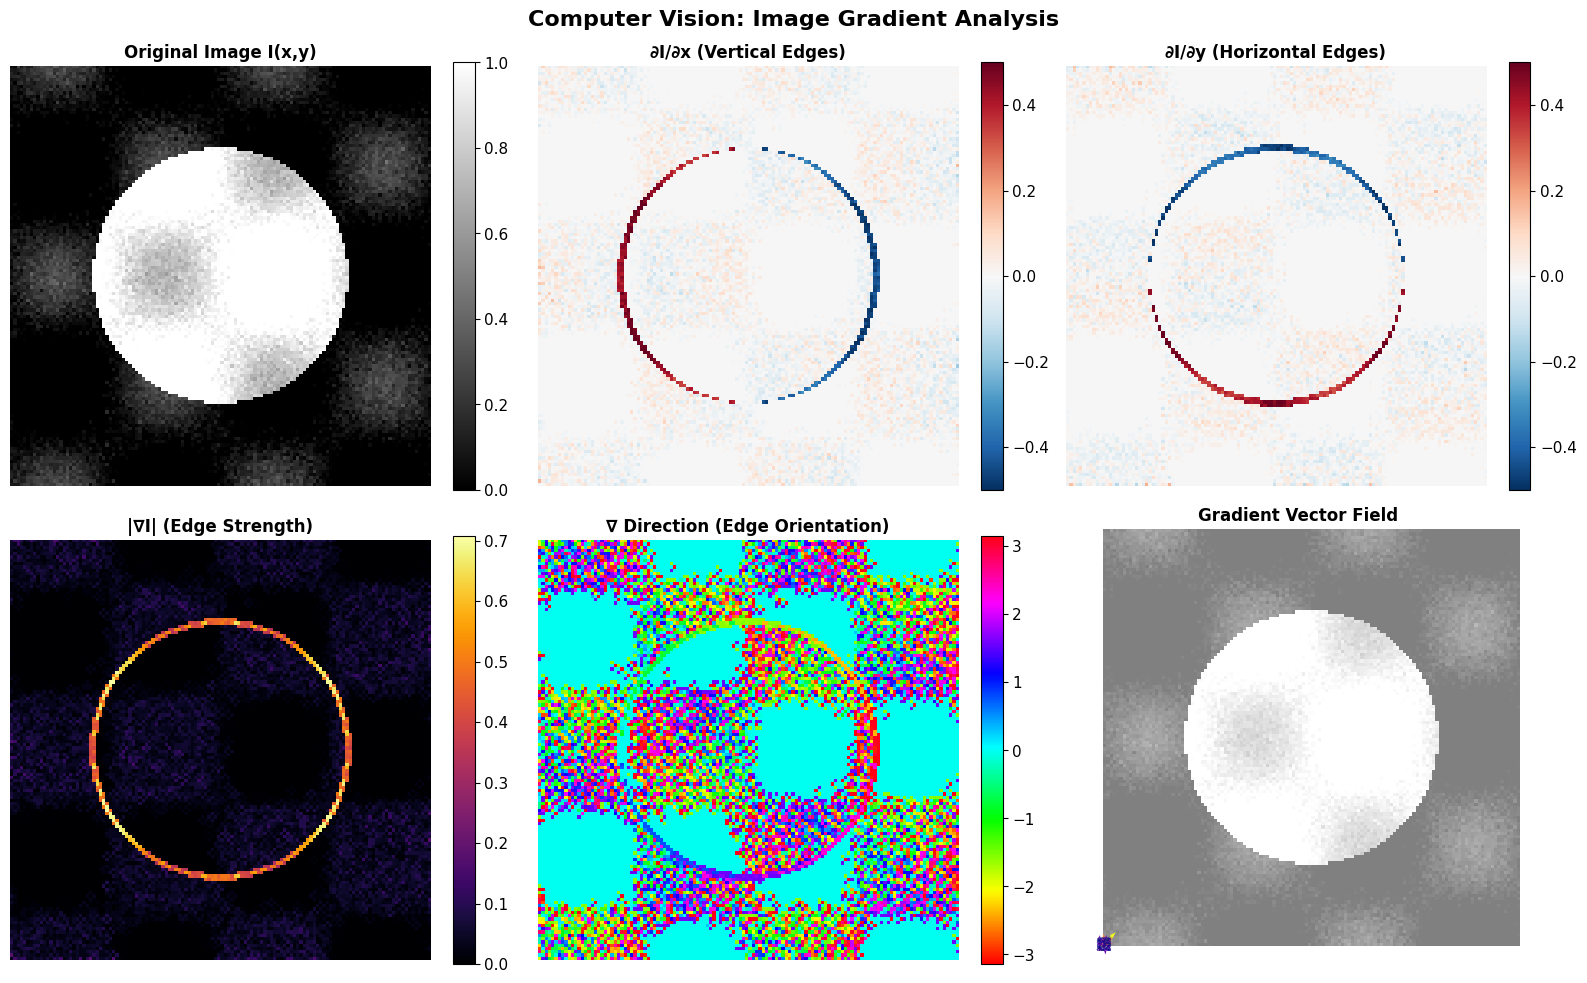


🖼️ Image Gradient Analysis:
   Image size: 128×128
   Max |∇I|: 0.707
   Mean |∇I|: 0.038

   Applications:
   • Edge Detection: Threshold |∇I| > 0.076
   • Corner Detection: High gradient in multiple directions
   • Feature Extraction: Histogram of Oriented Gradients (HOG)
   • Neural Networks: Convolutional filters learn gradient-like patterns


In [24]:
# ============================================
# Section 22 — Computer Vision: Image Gradients
# ============================================

def visualize_image_gradients():
    """Demonstrate image gradients using synthetic patterns."""

    # Create synthetic image with edges and patterns
    size = 128
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)

    # Synthetic image: combination of shapes
    image = np.zeros((size, size))
    # Circle
    circle = (X**2 + Y**2) < 1.5
    image[circle] = 1.0
    # Gradient pattern
    image += 0.3 * np.sin(3*X) * np.cos(3*Y)
    # Add noise
    image += 0.05 * np.random.randn(size, size)
    image = np.clip(image, 0, 1)

    # Compute gradients (Sobel-like)
    dy, dx = np.gradient(image)

    # Gradient magnitude
    grad_mag = np.sqrt(dx**2 + dy**2)

    # Gradient direction
    grad_dir = np.arctan2(dy, dx)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # Original image
    im0 = axes[0, 0].imshow(image, cmap='gray', origin='lower')
    axes[0, 0].set_title('Original Image I(x,y)', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

    # ∂I/∂x
    im1 = axes[0, 1].imshow(dx, cmap='RdBu_r', origin='lower')
    axes[0, 1].set_title('∂I/∂x (Vertical Edges)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

    # ∂I/∂y
    im2 = axes[0, 2].imshow(dy, cmap='RdBu_r', origin='lower')
    axes[0, 2].set_title('∂I/∂y (Horizontal Edges)', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

    # Gradient magnitude
    im3 = axes[1, 0].imshow(grad_mag, cmap='inferno', origin='lower')
    axes[1, 0].set_title('|∇I| (Edge Strength)', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

    # Gradient direction
    im4 = axes[1, 1].imshow(grad_dir, cmap='hsv', origin='lower')
    axes[1, 1].set_title('∇ Direction (Edge Orientation)', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

    # Gradient vector field (subsampled)
    step = 8
    axes[1, 2].imshow(image, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 2].quiver(X[::step, ::step], Y[::step, ::step], 
                     dx[::step, ::step], dy[::step, ::step],
                     grad_mag[::step, ::step], cmap='plasma',
                     scale=15, width=0.003)
    axes[1, 2].set_title('Gradient Vector Field', fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')

    plt.suptitle('Computer Vision: Image Gradient Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n🖼️ Image Gradient Analysis:")
    print(f"   Image size: {size}×{size}")
    print(f"   Max |∇I|: {grad_mag.max():.3f}")
    print(f"   Mean |∇I|: {grad_mag.mean():.3f}")
    print(f"\n   Applications:")
    print(f"   • Edge Detection: Threshold |∇I| > {grad_mag.mean()*2:.3f}")
    print(f"   • Corner Detection: High gradient in multiple directions")
    print(f"   • Feature Extraction: Histogram of Oriented Gradients (HOG)")
    print(f"   • Neural Networks: Convolutional filters learn gradient-like patterns")

visualize_image_gradients()


---

# Section 23 — Robotics Workspace

## Forward Kinematics

A robotic arm maps joint angles $\theta = (\theta_1, \theta_2)$ to end-effector position $(x, y)$:

$$
x = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)
$$

$$
y = L_1 \sin(\theta_1) + L_2 \sin(\theta_1 + \theta_2)
$$

## The Jacobian in Robotics

The Jacobian maps joint velocities to end-effector velocities:

$$
\begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix} = J(\theta) \begin{bmatrix} \dot{\theta}_1 \\ \dot{\theta}_2 \end{bmatrix}
$$

Where:

$$
J = \begin{bmatrix} 
-\sin(\theta_1) - \sin(\theta_1+\theta_2) & -\sin(\theta_1+\theta_2) \\
\cos(\theta_1) + \cos(\theta_1+\theta_2) & \cos(\theta_1+\theta_2)
\end{bmatrix}
$$

## Singularities

When $\det(J) = 0$, the arm loses a degree of freedom — this is a **kinematic singularity**.

> 🤖 **Application**: The Jacobian is essential for real-time control, inverse kinematics, and path planning in robotics.


In [25]:
# ============================================
# Section 23 — Robotics: 2-DOF Arm & Jacobian
# ============================================

def visualize_robotic_arm(theta1_deg=45, theta2_deg=-30, show_workspace=True):
    """Visualize a 2-DOF robotic arm and its Jacobian."""

    L1, L2 = 2.0, 1.5
    theta1 = np.deg2rad(theta1_deg)
    theta2 = np.deg2rad(theta2_deg)

    # Joint positions
    base = np.array([0, 0])
    joint1 = np.array([L1 * np.cos(theta1), L1 * np.sin(theta1)])
    end_effector = np.array([
        L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2),
        L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    ])

    # Jacobian
    J = np.array([
        [-L1*np.sin(theta1) - L2*np.sin(theta1+theta2), -L2*np.sin(theta1+theta2)],
        [L1*np.cos(theta1) + L2*np.cos(theta1+theta2), L2*np.cos(theta1+theta2)]
    ])

    det_J = np.linalg.det(J)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Left: Arm configuration
    ax1 = axes[0]

    # Draw links
    ax1.plot([base[0], joint1[0]], [base[1], joint1[1]], 'b-', linewidth=8, alpha=0.7, label='Link 1')
    ax1.plot([joint1[0], end_effector[0]], [joint1[1], end_effector[1]], 'r-', linewidth=8, alpha=0.7, label='Link 2')

    # Draw joints
    ax1.plot(base[0], base[1], 'ko', markersize=15, label='Base')
    ax1.plot(joint1[0], joint1[1], 'go', markersize=12, label='Joint 1')
    ax1.plot(end_effector[0], end_effector[1], 'm*', markersize=20, label='End Effector')

    # Draw Jacobian vectors (velocity ellipsoid)
    if abs(det_J) > 0.01:
        # Principal axes of velocity ellipsoid
        U, S, Vt = np.linalg.svd(J)
        for i, (s, u) in enumerate(zip(S, U.T)):
            color = 'purple' if i == 0 else 'orange'
            ax1.arrow(end_effector[0], end_effector[1], u[0]*s*0.3, u[1]*s*0.3,
                     head_width=0.1, head_length=0.08, fc=color, ec=color, linewidth=2,
                     label=f'Principal axis {i+1} (σ={s:.2f})')

    ax1.set_xlim(-4, 4)
    ax1.set_ylim(-4, 4)
    ax1.set_aspect('equal')
    ax1.set_title(f'2-DOF Robotic Arm\nθ₁={theta1_deg}°, θ₂={theta2_deg}°', fontsize=14, fontweight='bold')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.2)
    ax1.axvline(x=0, color='k', linestyle='--', alpha=0.2)

    # Right: Workspace and Jacobian info
    ax2 = axes[1]

    if show_workspace:
        # Sample workspace
        n_samples = 500
        t1_samp = np.random.uniform(-np.pi, np.pi, n_samples)
        t2_samp = np.random.uniform(-np.pi, np.pi, n_samples)
        x_ws = L1 * np.cos(t1_samp) + L2 * np.cos(t1_samp + t2_samp)
        y_ws = L1 * np.sin(t1_samp) + L2 * np.sin(t1_samp + t2_samp)
        ax2.scatter(x_ws, y_ws, c='lightblue', alpha=0.3, s=1, label='Workspace')

    # Current position
    ax2.plot(end_effector[0], end_effector[1], 'r*', markersize=15, label='Current Position')

    # Singularity visualization (det(J) = 0)
    # For 2-DOF arm: singularity when θ₂ = 0 or π (arm fully extended or folded)
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax2.set_aspect('equal')
    ax2.set_title('Workspace & Jacobian Analysis', fontsize=14, fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.2)
    ax2.axvline(x=0, color='k', linestyle='--', alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Jacobian info panel
    print(f"\n🤖 Robotics Analysis:")
    print(f"   Joint angles: θ₁={theta1_deg}°, θ₂={theta2_deg}°")
    print(f"   End effector: ({end_effector[0]:.3f}, {end_effector[1]:.3f})")
    print(f"\n   Jacobian Matrix J:")
    print(f"   [[{J[0,0]:.3f}, {J[0,1]:.3f}]")
    print(f"    [{J[1,0]:.3f}, {J[1,1]:.3f}]]")
    print(f"\n   det(J) = {det_J:.3f}")

    if abs(det_J) < 0.1:
        print(f"   ⚠️  NEAR SINGULARITY! Arm loses a degree of freedom.")
    else:
        U, S, Vt = np.linalg.svd(J)
        print(f"   Singular values: σ₁={S[0]:.3f}, σ₂={S[1]:.3f}")
        print(f"   Condition number: {S[0]/S[1]:.3f}")
        print(f"   ✅ Manipulable in all directions")

    print(f"\n   Forward Kinematics:")
    print(f"   x = L₁cos(θ₁) + L₂cos(θ₁+θ₂) = {end_effector[0]:.3f}")
    print(f"   y = L₁sin(θ₁) + L₂sin(θ₁+θ₂) = {end_effector[1]:.3f}")

interact(
    visualize_robotic_arm,
    theta1_deg=widgets.FloatSlider(min=-180, max=180, step=5, value=45, description='θ₁ (°):'),
    theta2_deg=widgets.FloatSlider(min=-180, max=180, step=5, value=-30, description='θ₂ (°):'),
    show_workspace=widgets.Checkbox(value=True, description='Show Workspace')
)


interactive(children=(FloatSlider(value=45.0, description='θ₁ (°):', max=180.0, min=-180.0, step=5.0), FloatSl…

<function __main__.visualize_robotic_arm(theta1_deg=45, theta2_deg=-30, show_workspace=True)>

---

# Section 24 — Probability Surface

## 2D Gaussian Distribution

The multivariate Gaussian is the foundation of probabilistic machine learning:

$$
p(x, y) = \frac{1}{2\pi|\Sigma|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)
$$

Where:
- $\boldsymbol{\mu} = (\mu_x, \mu_y)$: Mean vector (center location)
- $\Sigma = \begin{bmatrix} \sigma_x^2 & \rho\sigma_x\sigma_y \\ \rho\sigma_x\sigma_y & \sigma_y^2 \end{bmatrix}$: Covariance matrix (shape)
- $\rho$: Correlation coefficient

## Properties

- **Level curves** are ellipses
- **Gradient** points toward the mean (steepest ascent of probability)
- **Hessian** relates to precision matrix (inverse covariance)

> 🎲 **Application**: Gaussian distributions model uncertainty in Bayesian neural networks, Kalman filters, and generative models like VAEs and diffusion models.


In [26]:
# ============================================
# Section 24 — 2D Gaussian Probability Surface
# ============================================

def visualize_gaussian(mu_x=0, mu_y=0, sigma_x=1.0, sigma_y=1.0, rho=0.0):
    """Interactive 2D Gaussian distribution visualization."""

    x = np.linspace(-4, 4, 150)
    y = np.linspace(-4, 4, 150)
    X, Y = np.meshgrid(x, y)

    # Covariance matrix
    Sigma = np.array([[sigma_x**2, rho*sigma_x*sigma_y],
                      [rho*sigma_x*sigma_y, sigma_y**2]])

    # Compute PDF
    pos = np.dstack((X, Y))
    mu = np.array([mu_x, mu_y])

    det_Sigma = np.linalg.det(Sigma)
    inv_Sigma = np.linalg.inv(Sigma)

    diff = pos - mu
    Z = np.zeros_like(X)
    for i in range(len(x)):
        for j in range(len(y)):
            d = diff[j, i]
            Z[j, i] = np.exp(-0.5 * d @ inv_Sigma @ d) / (2 * np.pi * np.sqrt(det_Sigma))

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'surface', 'colspan': 2}, None],
               [{'type': 'contour'}, {'type': 'xy'}]],
        subplot_titles=('Probability Density Surface', 'Contour Plot (Level Curves)', 'Marginal Distributions'),
        row_heights=[0.5, 0.5]
    )

    # 3D Surface
    fig.add_trace(go.Surface(
        z=Z, x=X, y=Y,
        colorscale='Viridis',
        showscale=False,
        contours=dict(z=dict(show=True, usecolormap=True, project_z=True))
    ), row=1, col=1)

    # Contour plot
    fig.add_trace(go.Contour(
        z=Z, x=x, y=y,
        colorscale='Viridis',
        contours=dict(showlabels=True),
        colorbar=dict(title='p(x,y)', thickness=15, x=0.45)
    ), row=2, col=1)

    # Mark mean
    fig.add_trace(go.Scatter(
        x=[mu_x], y=[mu_y],
        mode='markers',
        marker=dict(size=12, color='red', symbol='x', line=dict(width=2, color='black')),
        name='Mean'
    ), row=2, col=1)

    # Marginal distributions
    marginal_x = Z.sum(axis=0) * (y[1] - y[0])
    marginal_y = Z.sum(axis=1) * (x[1] - x[0])

    fig.add_trace(go.Scatter(x=x, y=marginal_x, mode='lines', 
                            line=dict(color='blue', width=2), name='p(x)'), row=2, col=2)
    fig.add_trace(go.Scatter(x=y, y=marginal_y, mode='lines',
                            line=dict(color='red', width=2), name='p(y)'), row=2, col=2)

    fig.update_layout(
        title=dict(
            text=f'<b>2D Gaussian Distribution</b><br>'
                f'<span style="font-size:13px">μ=({mu_x},{mu_y}), σ_x={sigma_x}, σ_y={sigma_y}, ρ={rho}</span>',
            x=0.5, font=dict(size=16)
        ),
        height=800,
        width=1100,
        scene=dict(
            xaxis_title='x', yaxis_title='y', zaxis_title='p(x,y)',
            aspectratio=dict(x=1, y=1, z=0.6)
        )
    )

    fig.update_xaxes(title_text='x', row=2, col=2)
    fig.update_yaxes(title_text='Probability', row=2, col=2)

    fig.show()

    # Eigenvalue analysis
    eigenvalues, eigenvectors = np.linalg.eig(Sigma)

    print(f"\n🎲 2D Gaussian Analysis:")
    print(f"   Mean: μ = ({mu_x}, {mu_y})")
    print(f"   Covariance Matrix:")
    print(f"   [[{Sigma[0,0]:.3f}, {Sigma[0,1]:.3f}]")
    print(f"    [{Sigma[1,0]:.3f}, {Sigma[1,1]:.3f}]]")
    print(f"\n   Eigenvalues: λ₁={eigenvalues[0]:.3f}, λ₂={eigenvalues[1]:.3f}")
    print(f"   Principal axes directions:")
    print(f"   v₁ = ({eigenvectors[0,0]:.3f}, {eigenvectors[1,0]:.3f})")
    print(f"   v₂ = ({eigenvectors[0,1]:.3f}, {eigenvectors[1,1]:.3f})")
    print(f"\n   det(Σ) = {det_Sigma:.3f} (proportional to area of uncertainty ellipse)")
    print(f"   tr(Σ) = {np.trace(Sigma):.3f} (total variance)")

    if abs(rho) > 0.5:
        print(f"   ⚠️  Strong correlation: |ρ| = {abs(rho):.2f}")
    else:
        print(f"   ✅ Weak to moderate correlation")

interact(
    visualize_gaussian,
    mu_x=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0, description='μ_x:'),
    mu_y=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0, description='μ_y:'),
    sigma_x=widgets.FloatSlider(min=0.3, max=2, step=0.1, value=1.0, description='σ_x:'),
    sigma_y=widgets.FloatSlider(min=0.3, max=2, step=0.1, value=1.0, description='σ_y:'),
    rho=widgets.FloatSlider(min=-0.9, max=0.9, step=0.1, value=0.0, description='ρ:')
)


interactive(children=(FloatSlider(value=0.0, description='μ_x:', max=2.0, min=-2.0), FloatSlider(value=0.0, de…

<function __main__.visualize_gaussian(mu_x=0, mu_y=0, sigma_x=1.0, sigma_y=1.0, rho=0.0)>

---

# Section 25 — Machine Learning Optimization Dashboard

## Integrated Optimization View

This dashboard combines all key optimization concepts into a single interactive view:

- **Loss Surface**: The terrain we're navigating
- **Gradient Field**: The compass pointing uphill
- **Optimization Path**: The trajectory of gradient descent
- **Learning Rate Control**: How aggressively we step
- **Parameter Updates**: Real-time weight changes

## The Optimization Loop

```
1. Compute loss L(θ)
2. Compute gradient ∇L(θ)
3. Update: θ ← θ - η∇L(θ)
4. Repeat until convergence
```

> 🎛️ **Dashboard**: Control every aspect of the optimization process and watch how the landscape, gradients, and path interact.


In [27]:
# ============================================
# Section 25 — ML Optimization Dashboard
# ============================================

def optimization_dashboard(landscape='Bowl', lr=0.1, momentum=0.0, n_steps=50):
    """Comprehensive optimization dashboard."""

    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)

    if landscape == 'Bowl':
        Z = X**2 + Y**2
        def grad(px, py):
            return np.array([2*px, 2*py])
    elif landscape == 'Saddle':
        Z = X**2 - Y**2 + 0.1*(X**2 + Y**2)
        def grad(px, py):
            return np.array([2.2*px, -1.8*py])
    elif landscape == 'Rosenbrock':
        Z = (1-X)**2 + 100*(Y-X**2)**2
        def grad(px, py):
            return np.array([-2*(1-px) - 400*px*(py-px**2), 200*(py-px**2)])
    elif landscape == 'Ripple':
        Z = np.sin(2*X) * np.cos(2*Y) + 0.05*(X**2 + Y**2)
        def grad(px, py):
            return np.array([2*np.cos(2*px)*np.cos(2*py) + 0.1*px,
                           -2*np.sin(2*px)*np.sin(2*py) + 0.1*py])

    # Run optimization with momentum
    pos = np.array([2.5, 2.0])
    velocity = np.array([0.0, 0.0])
    path = [pos.copy()]
    losses = []

    for _ in range(n_steps):
        g = grad(pos[0], pos[1])
        velocity = momentum * velocity - lr * g
        pos = pos + velocity
        path.append(pos.copy())

        if landscape == 'Bowl':
            losses.append(pos[0]**2 + pos[1]**2)
        elif landscape == 'Saddle':
            losses.append(pos[0]**2 - pos[1]**2 + 0.1*(pos[0]**2 + pos[1]**2))
        elif landscape == 'Rosenbrock':
            losses.append((1-pos[0])**2 + 100*(pos[1]-pos[0]**2)**2)
        elif landscape == 'Ripple':
            losses.append(np.sin(2*pos[0])*np.cos(2*pos[1]) + 0.05*(pos[0]**2+pos[1]**2))

        if np.linalg.norm(g) < 0.001 or np.linalg.norm(pos) > 10:
            break

    path = np.array(path)

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'contour'}, {'type': 'xy'}],
               [{'type': 'xy'}, {'type': 'xy'}]],
        subplot_titles=('Loss Surface + GD Path', 'Loss vs Iteration', 
                       'Parameter Trajectory θ₁', 'Parameter Trajectory θ₂'),
        vertical_spacing=0.12
    )

    # Contour with path
    fig.add_trace(go.Contour(
        z=Z, x=x, y=y,
        colorscale='Viridis',
        contours=dict(showlabels=True),
        colorbar=dict(title='Loss', thickness=15, x=0.45),
        name='Loss Surface'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=path[:, 0], y=path[:, 1],
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=6, color='red'),
        name='GD Path'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=[path[0, 0]], y=[path[0, 1]],
        mode='markers',
        marker=dict(size=12, color='green', symbol='circle'),
        name='Start'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=[path[-1, 0]], y=[path[-1, 1]],
        mode='markers',
        marker=dict(size=12, color='blue', symbol='star'),
        name='End'
    ), row=1, col=1)

    # Loss curve
    fig.add_trace(go.Scatter(
        x=list(range(len(losses))), y=losses,
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=4),
        name='Loss'
    ), row=1, col=2)

    # Theta 1 trajectory
    fig.add_trace(go.Scatter(
        x=list(range(len(path))), y=path[:, 0],
        mode='lines',
        line=dict(color='blue', width=2),
        name='θ₁'
    ), row=2, col=1)

    # Theta 2 trajectory
    fig.add_trace(go.Scatter(
        x=list(range(len(path))), y=path[:, 1],
        mode='lines',
        line=dict(color='orange', width=2),
        name='θ₂'
    ), row=2, col=2)

    fig.update_layout(
        title=dict(
            text=f'<b>Optimization Dashboard</b><br>'
                f'<span style="font-size:13px">{landscape} | LR={lr} | Momentum={momentum}</span>',
            x=0.5, font=dict(size=16)
        ),
        height=800,
        width=1100,
        showlegend=False
    )

    fig.update_xaxes(title_text='θ₁', row=1, col=1)
    fig.update_yaxes(title_text='θ₂', row=1, col=1)
    fig.update_xaxes(title_text='Iteration', row=1, col=2)
    fig.update_yaxes(title_text='Loss', row=1, col=2)
    fig.update_xaxes(title_text='Iteration', row=2, col=1)
    fig.update_yaxes(title_text='θ₁', row=2, col=1)
    fig.update_xaxes(title_text='Iteration', row=2, col=2)
    fig.update_yaxes(title_text='θ₂', row=2, col=2)

    fig.show()

    print(f"\n🎛️ Optimization Dashboard Results:")
    print(f"   Landscape: {landscape}")
    print(f"   Learning rate: {lr}")
    print(f"   Momentum: {momentum}")
    print(f"   Steps: {len(path)-1}")
    print(f"   Initial loss: {losses[0]:.4f}")
    print(f"   Final loss: {losses[-1]:.4f}")
    print(f"   Final params: θ₁={path[-1,0]:.4f}, θ₂={path[-1,1]:.4f}")

    if losses[-1] < 0.01:
        print(f"   ✅ Converged successfully!")
    elif losses[-1] > losses[0]:
        print(f"   ❌ Diverged! Reduce learning rate.")
    else:
        print(f"   ⏳ Still converging...")

interact(
    optimization_dashboard,
    landscape=widgets.Dropdown(
        options=['Bowl', 'Saddle', 'Rosenbrock', 'Ripple'],
        value='Bowl',
        description='Landscape:'
    ),
    lr=widgets.FloatLogSlider(min=-3, max=0, step=0.1, value=0.1, description='LR:'),
    momentum=widgets.FloatSlider(min=0, max=0.9, step=0.1, value=0.0, description='Momentum:'),
    n_steps=widgets.IntSlider(min=10, max=200, step=10, value=50, description='Steps:')
)


interactive(children=(Dropdown(description='Landscape:', options=('Bowl', 'Saddle', 'Rosenbrock', 'Ripple'), v…

<function __main__.optimization_dashboard(landscape='Bowl', lr=0.1, momentum=0.0, n_steps=50)>

---

# Section 26 — AI Mathematics Playground

## The Ultimate Interactive Dashboard

This playground integrates all multivariable calculus concepts into a single unified interface:

- **3D Surface**: Visualize $f(x, y)$
- **Contour Plot**: See level curves
- **Gradient Vector**: Direction of steepest ascent
- **Gradient Magnitude**: Steepness heatmap
- **Tangent Plane**: Local linear approximation
- **Directional Derivative**: Rate of change in any direction
- **Optimization Animation**: Watch gradient descent in action

## Mathematical Connections

All these concepts are deeply connected:

$$
\text{Surface} \xrightarrow{\text{level curves}} \text{Contour} \xrightarrow{\nabla} \text{Gradient} \xrightarrow{\cdot \mathbf{u}} \text{Directional Derivative} \xrightarrow{\text{linear approx}} \text{Tangent Plane} \xrightarrow{-\eta\nabla} \text{Optimization}
$$

> 🎮 **Playground**: Switch between functions and explore how all calculus concepts interact in real-time.


In [28]:
# ============================================
# Section 26 — AI Mathematics Playground
# ============================================

def ai_math_playground(func_name='Paraboloid', x0=1.0, y0=0.5, angle=45, show_all=True):
    """Comprehensive mathematics playground."""

    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)

    funcs = {
        'Paraboloid': (X**2 + Y**2, 'x² + y²'),
        'Saddle': (X**2 - Y**2, 'x² - y²'),
        'Gaussian': (np.exp(-(X**2 + Y**2)/2), 'exp(-(x²+y²)/2)'),
        'Sinusoidal': (np.sin(X) * np.cos(Y), 'sin(x)cos(y)'),
        'Ripple': (np.sin(np.sqrt(X**2 + Y**2)) / (np.sqrt(X**2 + Y**2) + 0.1), 'sin(√(x²+y²))/√(x²+y²)')
    }

    Z, eq = funcs[func_name]

    # Compute derivatives at (x0, y0)
    dy, dx = np.gradient(Z, y, x)

    # Find nearest grid point
    ix = np.argmin(np.abs(x - x0))
    iy = np.argmin(np.abs(y - y0))

    dfdx = dx[iy, ix]
    dfdy = dy[iy, ix]
    grad = np.array([dfdx, dfdy])
    grad_mag = np.linalg.norm(grad)
    z0 = Z[iy, ix]

    # Directional derivative
    u = np.array([np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))])
    D_u_f = np.dot(grad, u)

    # Tangent plane
    Z_plane = z0 + dfdx * (X - x0) + dfdy * (Y - y0)

    fig = plt.figure(figsize=(18, 12))

    # 1. 3D Surface + Tangent Plane
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5, edgecolor='none')
    if show_all:
        ax1.plot_surface(X, Y, Z_plane, cmap='coolwarm', alpha=0.4, edgecolor='none')
    ax1.scatter([x0], [y0], [z0], color='red', s=100)
    ax1.set_title(f'3D Surface: {eq}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('z')

    # 2. Contour + Gradient
    ax2 = fig.add_subplot(2, 3, 2)
    cs = ax2.contour(X, Y, Z, levels=15, cmap='viridis')
    ax2.clabel(cs, inline=True, fontsize=8)
    ax2.plot(x0, y0, 'ro', markersize=10)
    if show_all:
        ax2.arrow(x0, y0, dfdx*0.5/grad_mag, dfdy*0.5/grad_mag,
                 head_width=0.12, head_length=0.08, fc='green', ec='green', linewidth=2,
                 label='∇f')
        ax2.arrow(x0, y0, u[0]*0.8, u[1]*0.8,
                 head_width=0.12, head_length=0.08, fc='red', ec='red', linewidth=2,
                 label=f'u ({angle}°)')
    ax2.set_title('Contour + Vectors', fontsize=12, fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_aspect('equal')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Gradient Magnitude
    ax3 = fig.add_subplot(2, 3, 3)
    grad_mag_full = np.sqrt(dx**2 + dy**2)
    im3 = ax3.imshow(grad_mag_full, extent=[x.min(), x.max(), y.min(), y.max()], 
                     origin='lower', cmap='inferno', aspect='auto')
    ax3.plot(x0, y0, 'wo', markersize=8)
    ax3.set_title('|∇f| Heatmap', fontsize=12, fontweight='bold')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    plt.colorbar(im3, ax=ax3, label='|∇f|')

    # 4. Directional Derivative Circle
    ax4 = fig.add_subplot(2, 3, 4, projection='polar')
    angles = np.linspace(0, 2*np.pi, 100)
    D_values = [np.dot(grad, [np.cos(a), np.sin(a)]) for a in angles]
    ax4.plot(angles, D_values, 'b-', linewidth=2)
    ax4.plot(np.deg2rad(angle), D_u_f, 'ro', markersize=10)
    ax4.set_title('D_u f vs Direction', fontsize=12, fontweight='bold')
    ax4.set_rticks([])

    # 5. Tangent Plane Error
    ax5 = fig.add_subplot(2, 3, 5)
    error = np.abs(Z - Z_plane)
    im5 = ax5.imshow(error, extent=[x.min(), x.max(), y.min(), y.max()], 
                     origin='lower', cmap='plasma', aspect='auto')
    ax5.plot(x0, y0, 'wo', markersize=8)
    ax5.set_title('Approximation Error', fontsize=12, fontweight='bold')
    ax5.set_xlabel('x')
    ax5.set_ylabel('y')
    plt.colorbar(im5, ax=ax5, label='|f - plane|')

    # 6. Info Panel
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')

    info = f"""
    🤖 AI MATHEMATICS PLAYGROUND

    Function: f(x,y) = {eq}

    Point: ({x0:.3f}, {y0:.3f})
    f({x0:.3f}, {y0:.3f}) = {z0:.3f}

    ─────────────────────────────
    GRADIENT:
      ∇f = ({dfdx:.3f}, {dfdy:.3f})
      |∇f| = {grad_mag:.3f}

    DIRECTIONAL DERIVATIVE:
      Direction: {angle}°
      u = ({u[0]:.3f}, {u[1]:.3f})
      D_u f = ∇f · u = {D_u_f:.3f}

    TANGENT PLANE:
      z = {z0:.3f} + {dfdx:.3f}(x-{x0:.3f}) + {dfdy:.3f}(y-{y0:.3f})

    ─────────────────────────────
    OPTIMIZATION:
      Steepest ascent: {grad_mag:.3f} in direction of ∇f
      Steepest descent: {-grad_mag:.3f} in direction of -∇f
      Gradient step (η=0.1): ({x0 - 0.1*dfdx:.3f}, {y0 - 0.1*dfdy:.3f})
    """

    ax6.text(0.05, 0.5, info, transform=ax6.transAxes, fontsize=10,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6))

    plt.suptitle(f'AI Mathematics Playground: {func_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(
    ai_math_playground,
    func_name=widgets.Dropdown(
        options=['Paraboloid', 'Saddle', 'Gaussian', 'Sinusoidal', 'Ripple'],
        value='Paraboloid',
        description='Function:'
    ),
    x0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1.0, description='x₀:'),
    y0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='y₀:'),
    angle=widgets.FloatSlider(min=0, max=360, step=5, value=45, description='Angle (°):'),
    show_all=widgets.Checkbox(value=True, description='Show All Overlays')
)


interactive(children=(Dropdown(description='Function:', options=('Paraboloid', 'Saddle', 'Gaussian', 'Sinusoid…

<function __main__.ai_math_playground(func_name='Paraboloid', x0=1.0, y0=0.5, angle=45, show_all=True)>

---

# Section 27 — Capstone Visualization

## The Journey: From Functions to Modern AI

This capstone ties together the entire chapter, showing how multivariable calculus concepts build upon each other to power modern AI systems.

## The Pipeline

```
Multivariable Function
        ↓
    3D Surface
        ↓
   Contour Map
        ↓
Partial Derivatives
        ↓
  Gradient Vector
        ↓
Directional Derivative
        ↓
   Tangent Plane
        ↓
Optimization Landscape
        ↓
  Gradient Descent
        ↓
Neural Network Loss
        ↓
    Modern AI
```

## The Big Picture

Every concept in this notebook connects to real AI systems:

| Calculus Concept | AI Application |
|-----------------|----------------|
| Partial Derivatives | Backpropagation |
| Gradient | Weight updates in SGD, Adam |
| Hessian | Second-order optimization, curvature analysis |
| Jacobian | Normalizing flows, invertible networks |
| Chain Rule | Automatic differentiation |
| Directional Derivative | Sensitivity analysis, adversarial attacks |
| Tangent Plane | Local linearization, trust regions |
| Double Integral | Expected loss, Bayesian inference |

> 🌟 **Final Insight**: Multivariable calculus is not just a mathematical subject — it is the **visual and computational language** that makes modern AI possible. Every gradient update, every neural network layer, every optimization step is an application of the concepts you've explored in this notebook.


C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20084\630247021.py:142: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])
e:\Organization\ML-Verse\mlverse-machine-learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


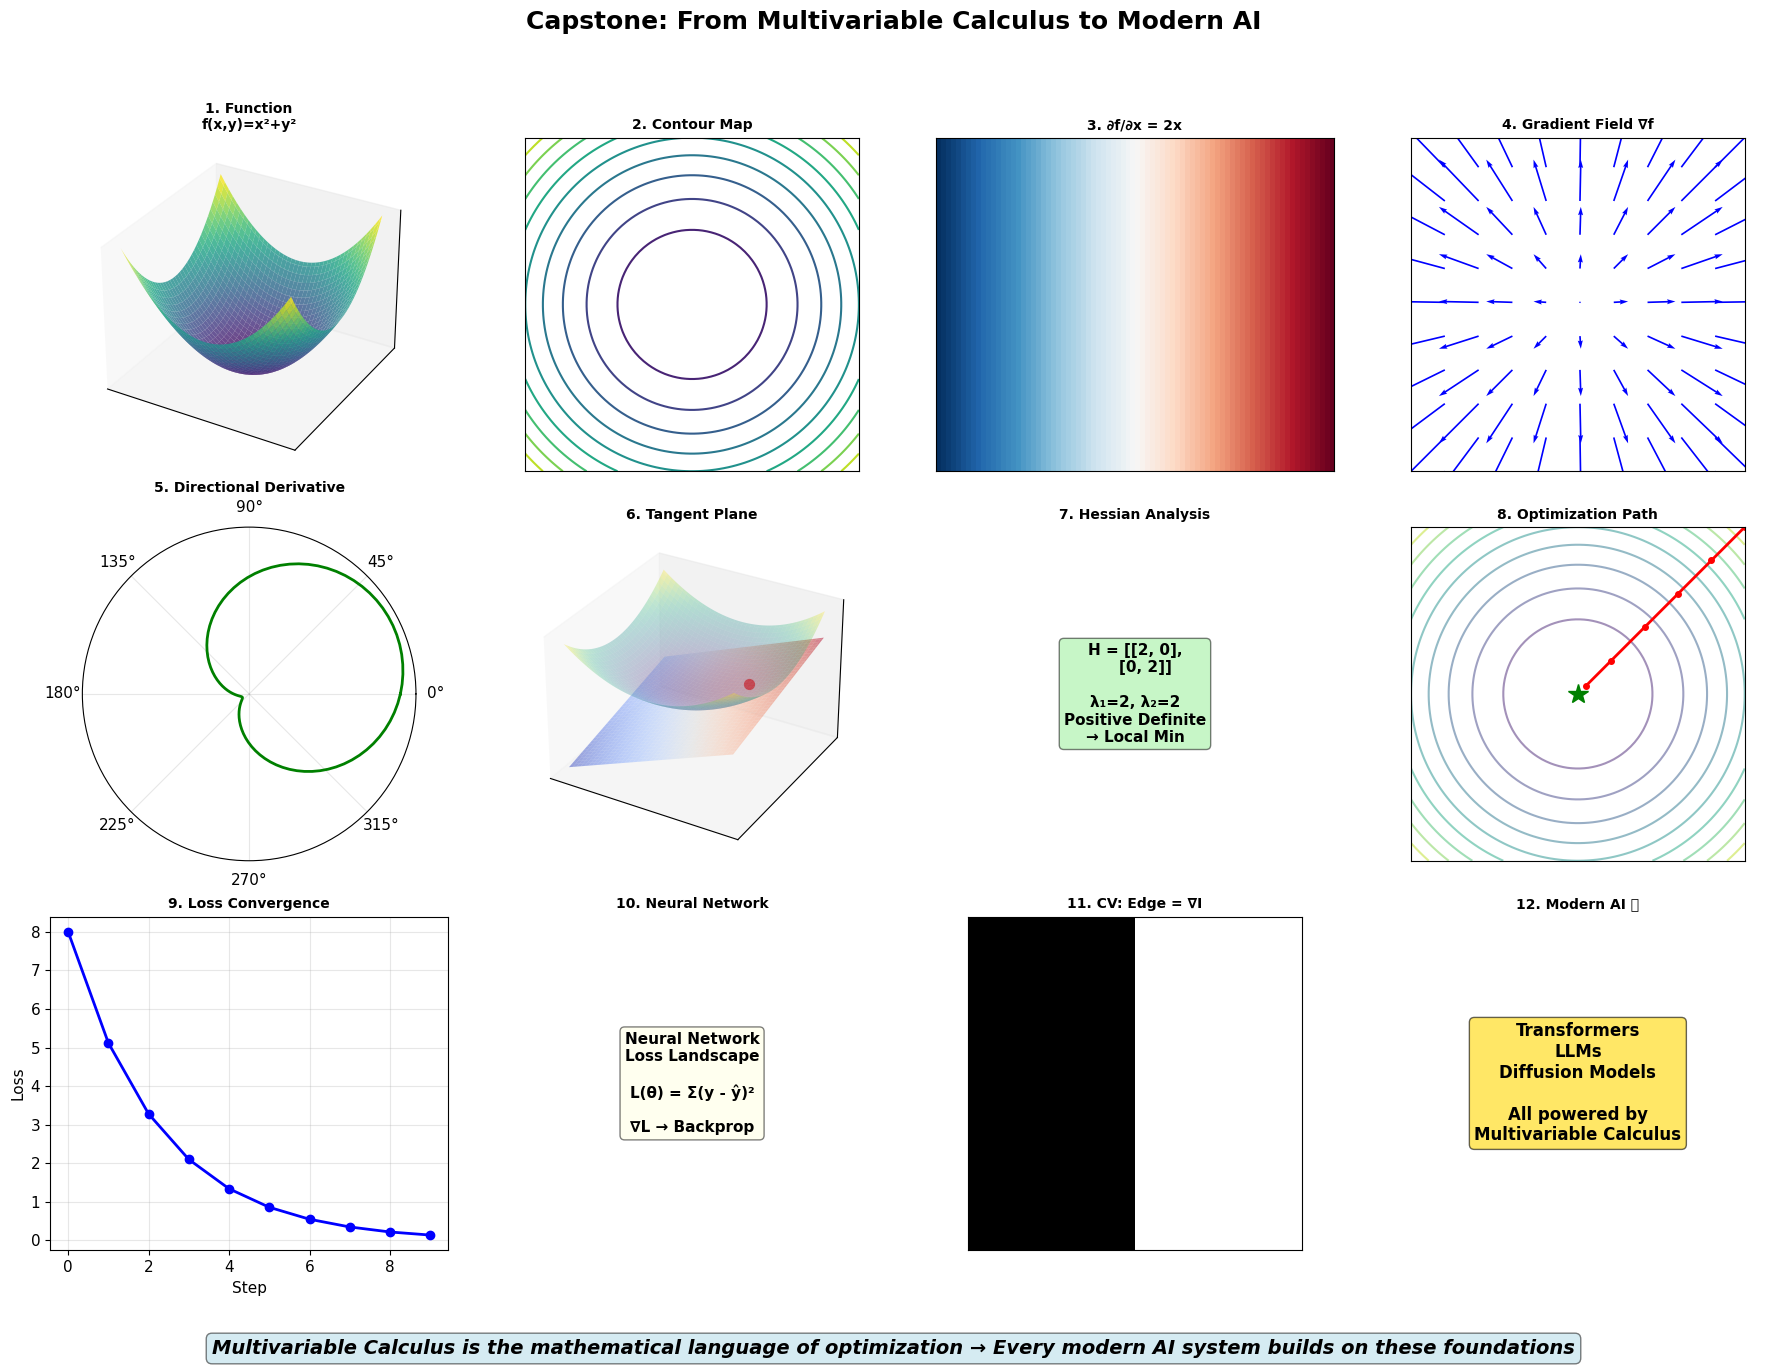


  🌟 CAPSTONE: THE COMPLETE JOURNEY

  This visualization shows how every concept in multivariable
  calculus connects to form the foundation of modern AI:

  1. Functions → Surfaces → Landscapes to optimize
  2. Gradients → Direction of improvement → How neural networks learn
  3. Hessians → Curvature → Optimization acceleration
  4. Chain Rule → Backpropagation → Training deep networks
  5. Jacobians → Transformations → Normalizing flows, robotics
  6. Probability → Distributions → Generative models, uncertainty

  Every gradient update in GPT, every diffusion step in DALL-E,
  every optimization in AlphaGo — all are applications of the
  concepts explored in this notebook.


In [29]:
# ============================================
# Section 27 — Capstone: The Complete Journey
# ============================================

def capstone_journey():
    """Create the capstone visualization showing the journey from calculus to AI."""

    fig = plt.figure(figsize=(18, 14))

    # Create a comprehensive multi-panel view
    x = np.linspace(-2, 2, 80)
    y = np.linspace(-2, 2, 80)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2  # Paraboloid

    # 1. The Function
    ax1 = fig.add_subplot(3, 4, 1, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.set_title('1. Function\nf(x,y)=x²+y²', fontsize=10, fontweight='bold')
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_zticks([])

    # 2. Contour Map
    ax2 = fig.add_subplot(3, 4, 2)
    cs = ax2.contour(X, Y, Z, levels=10, cmap='viridis')
    ax2.set_title('2. Contour Map', fontsize=10, fontweight='bold')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_aspect('equal')

    # 3. Partial Derivatives
    ax3 = fig.add_subplot(3, 4, 3)
    dZdx = 2*X
    im3 = ax3.imshow(dZdx, extent=[-2,2,-2,2], origin='lower', cmap='RdBu_r', aspect='auto')
    ax3.set_title('3. ∂f/∂x = 2x', fontsize=10, fontweight='bold')
    ax3.set_xticks([])
    ax3.set_yticks([])

    # 4. Gradient Field
    ax4 = fig.add_subplot(3, 4, 4)
    dy, dx = np.gradient(Z, y, x)
    step = 8
    ax4.quiver(X[::step, ::step], Y[::step, ::step], 
              dx[::step, ::step], dy[::step, ::step],
              color='blue', scale=20, width=0.005)
    ax4.set_title('4. Gradient Field ∇f', fontsize=10, fontweight='bold')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_aspect('equal')
    ax4.set_xlim(-2, 2)
    ax4.set_ylim(-2, 2)

    # 5. Directional Derivative
    ax5 = fig.add_subplot(3, 4, 5, projection='polar')
    grad = np.array([2, 1])
    angles = np.linspace(0, 2*np.pi, 100)
    D_vals = [np.dot(grad, [np.cos(a), np.sin(a)]) for a in angles]
    ax5.plot(angles, D_vals, 'g-', linewidth=2)
    ax5.set_title('5. Directional Derivative', fontsize=10, fontweight='bold')
    ax5.set_rticks([])

    # 6. Tangent Plane
    ax6 = fig.add_subplot(3, 4, 6, projection='3d')
    x0, y0 = 1, 0.5
    z0 = x0**2 + y0**2
    Z_plane = z0 + 2*x0*(X-x0) + 2*y0*(Y-y0)
    ax6.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')
    ax6.plot_surface(X, Y, Z_plane, cmap='coolwarm', alpha=0.5, edgecolor='none')
    ax6.scatter([x0], [y0], [z0], color='red', s=50)
    ax6.set_title('6. Tangent Plane', fontsize=10, fontweight='bold')
    ax6.set_xticks([])
    ax6.set_yticks([])
    ax6.set_zticks([])

    # 7. Hessian / Curvature
    ax7 = fig.add_subplot(3, 4, 7)
    ax7.text(0.5, 0.5, 'H = [[2, 0],\n    [0, 2]]\n\nλ₁=2, λ₂=2\nPositive Definite\n→ Local Min', 
            ha='center', va='center', fontsize=11, fontweight='bold',
            transform=ax7.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    ax7.set_title('7. Hessian Analysis', fontsize=10, fontweight='bold')
    ax7.axis('off')

    # 8. Optimization Landscape
    ax8 = fig.add_subplot(3, 4, 8)
    # Simulate optimization path
    theta_path = np.array([[2, 2], [1.6, 1.6], [1.2, 1.2], [0.8, 0.8], [0.4, 0.4], [0.1, 0.1]])
    ax8.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.5)
    ax8.plot(theta_path[:, 0], theta_path[:, 1], 'r.-', markersize=8, linewidth=2)
    ax8.plot(0, 0, 'g*', markersize=15)
    ax8.set_title('8. Optimization Path', fontsize=10, fontweight='bold')
    ax8.set_xticks([])
    ax8.set_yticks([])
    ax8.set_aspect('equal')

    # 9. Gradient Descent
    ax9 = fig.add_subplot(3, 4, 9)
    losses = [8, 5.12, 3.28, 2.1, 1.34, 0.86, 0.55, 0.35, 0.22, 0.14]
    ax9.plot(losses, 'b-', linewidth=2, marker='o')
    ax9.set_title('9. Loss Convergence', fontsize=10, fontweight='bold')
    ax9.set_xlabel('Step')
    ax9.set_ylabel('Loss')
    ax9.grid(True, alpha=0.3)

    # 10. Neural Network
    ax10 = fig.add_subplot(3, 4, 10)
    ax10.text(0.5, 0.5, 'Neural Network\nLoss Landscape\n\nL(θ) = Σ(y - ŷ)²\n\n∇L → Backprop', 
             ha='center', va='center', fontsize=11, fontweight='bold',
             transform=ax10.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    ax10.set_title('10. Neural Network', fontsize=10, fontweight='bold')
    ax10.axis('off')

    # 11. Computer Vision
    ax11 = fig.add_subplot(3, 4, 11)
    # Simple edge pattern
    edge = np.zeros((20, 20))
    edge[:, 10:] = 1
    ax11.imshow(edge, cmap='gray')
    ax11.set_title('11. CV: Edge = ∇I', fontsize=10, fontweight='bold')
    ax11.set_xticks([])
    ax11.set_yticks([])

    # 12. Modern AI
    ax12 = fig.add_subplot(3, 4, 12)
    ax12.text(0.5, 0.5, 'Transformers\nLLMs\nDiffusion Models\n\nAll powered by\nMultivariable Calculus', 
             ha='center', va='center', fontsize=12, fontweight='bold',
             transform=ax12.transAxes,
             bbox=dict(boxstyle='round', facecolor='gold', alpha=0.6))
    ax12.set_title('12. Modern AI 🚀', fontsize=10, fontweight='bold')
    ax12.axis('off')

    # Add arrows between panels (conceptual)
    fig.text(0.5, 0.02, 
            'Multivariable Calculus is the mathematical language of optimization → Every modern AI system builds on these foundations',
            ha='center', fontsize=14, fontweight='bold', style='italic',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.suptitle('Capstone: From Multivariable Calculus to Modern AI', 
                fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    print("\n" + "="*70)
    print("  🌟 CAPSTONE: THE COMPLETE JOURNEY")
    print("="*70)
    print("\n  This visualization shows how every concept in multivariable")
    print("  calculus connects to form the foundation of modern AI:")
    print()
    print("  1. Functions → Surfaces → Landscapes to optimize")
    print("  2. Gradients → Direction of improvement → How neural networks learn")
    print("  3. Hessians → Curvature → Optimization acceleration")
    print("  4. Chain Rule → Backpropagation → Training deep networks")
    print("  5. Jacobians → Transformations → Normalizing flows, robotics")
    print("  6. Probability → Distributions → Generative models, uncertainty")
    print()
    print("  Every gradient update in GPT, every diffusion step in DALL-E,")
    print("  every optimization in AlphaGo — all are applications of the")
    print("  concepts explored in this notebook.")
    print("="*70)

capstone_journey()


---

# Final Summary

## ✅ Concepts Mastered

This interactive notebook has covered the complete spectrum of multivariable calculus with AI applications:

### Core Calculus
- ✅ **Multivariable Functions** — $f(x, y)$ and their 3D surfaces
- ✅ **Surface Plots** — Interactive 3D visualizations with Plotly
- ✅ **Contour Maps** — Level curves and topographic interpretation
- ✅ **Partial Derivatives** — Rates of change in each direction
- ✅ **Higher-Order Derivatives** — Hessian matrix and curvature

### Gradient Methods
- ✅ **Gradient Vectors** — Direction of steepest ascent
- ✅ **Gradient Fields** — Vector fields and streamlines
- ✅ **Directional Derivatives** — Rate of change in any direction
- ✅ **Gradient Magnitude** — Steepness and flat region detection

### Geometry
- ✅ **Tangent Planes** — Local linear approximations
- ✅ **Normal Vectors** — Perpendicularity to surfaces
- ✅ **Chain Rule** — Backpropagation in computational graphs
- ✅ **Total Differential** — Combined effect of small changes

### Integration
- ✅ **Double Integrals** — Volume under surfaces
- ✅ **Triple Integrals** — Accumulation in 3D space

### Advanced Topics
- ✅ **Jacobian Matrix** — Coordinate transformations
- ✅ **Hessian Matrix** — Critical point classification

### Optimization & AI
- ✅ **Optimization Landscapes** — Minima, maxima, saddles
- ✅ **Gradient Descent** — Iterative optimization with animations
- ✅ **ML Loss Surfaces** — MSE, cross-entropy, non-convex losses
- ✅ **Neural Network Loss** — Simplified 2D visualization
- ✅ **Computer Vision** — Image gradients and edge detection
- ✅ **Robotics** — Forward kinematics and Jacobian
- ✅ **Probability** — 2D Gaussian distributions

---

# Final Insight

> **Multivariable Calculus is the visual and mathematical language of optimization.**
>
> Every modern AI system — from gradient descent in neural networks to transformers and large language models — relies on the concepts explored in this notebook.
>
> The journey from $f(x, y)$ to GPT-4 is a journey through partial derivatives, gradients, Hessians, Jacobians, and optimization landscapes. Understanding these concepts doesn't just make you better at math — it makes you better at AI.

## Continue Your Journey

- **Linear Algebra** — The language of vector spaces and transformations
- **Probability & Statistics** — The language of uncertainty and data
- **Optimization Theory** — The language of convergence and efficiency
- **Differential Equations** — The language of dynamical systems

**The MLVerse-Math repository awaits. Keep exploring. 🚀**


In [30]:
# ============================================
# Notebook Complete
# ============================================

print("="*70)
print("  🎉 NOTEBOOK COMPLETE: Multivariable Calculus Visualization")
print("="*70)
print()
print("  Thank you for exploring this interactive notebook!")
print()
print("  Key takeaways:")
print("  • Visual intuition comes before mathematical complexity")
print("  • Every calculus concept has a direct AI application")
print("  • Interactive exploration accelerates understanding")
print("  • The math of optimization IS the math of AI")
print()
print("  For more: github.com/MLVerse-Math")
print("="*70)


  🎉 NOTEBOOK COMPLETE: Multivariable Calculus Visualization

  Thank you for exploring this interactive notebook!

  Key takeaways:
  • Visual intuition comes before mathematical complexity
  • Every calculus concept has a direct AI application
  • Interactive exploration accelerates understanding
  • The math of optimization IS the math of AI

  For more: github.com/MLVerse-Math
